In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


In [56]:
import numpy as np

group_order = ["0-14", "15-24", "25-44", "45-64", "65-80", "81+"]

# GBD 2023 (USA, both sexes) age-band data: (value, lower, upper), per 100,000 population.
# Coarse age groups are formed by averaging the 5-year GBD bands that fall inside them.
gbd_prev_bands = {
    "0-14":  [(16.40, 13.09, 20.22)],
    "15-24": [(66.23, 55.21, 80.24), (83.97, 68.73, 99.47)],
    "25-44": [(113.70, 95.83, 134.86), (162.28, 133.44, 194.92),
              (235.48, 195.66, 277.09), (334.00, 270.40, 397.71)],
    "45-64": [(451.69, 377.01, 533.40), (585.85, 493.71, 688.36),
              (743.00, 632.10, 854.64), (927.29, 809.13, 1074.66)],
    "65-80": [(1125.12, 974.07, 1295.13), (1245.33, 1104.87, 1412.92), (1220.64, 1078.64, 1370.26)],
    "81+":   [(1095.49, 977.05, 1215.84), (946.18, 841.58, 1064.97),
              (803.36, 717.73, 907.17), (650.27, 574.29, 745.29)],
}

gbd_inci_bands = {
    "0-14":  [(4.09, 3.38, 4.93)],
    "15-24": [(4.83, 3.42, 6.73), (5.46, 3.85, 7.43)],
    "25-44": [(9.30, 5.83, 13.21), (14.29, 10.68, 18.26), (20.40, 12.21, 28.34), (26.17, 18.13, 34.07)],
    "45-64": [(31.44, 20.10, 43.02), (37.38, 25.76, 48.14), (44.16, 29.62, 63.00), (53.31, 35.15, 74.36)],
    "65-80": [(62.64, 43.27, 84.35), (55.70, 34.36, 77.77), (34.31, 24.06, 45.52)],
    "81+":   [(20.74, 12.50, 30.91), (14.79, 8.94, 22.04), (8.70, 5.27, 12.97), (2.23, 1.35, 3.32)],
}

def aggregate_gbd(bands_dict, order):
    means, los, his = [], [], []
    for g in order:
        arr = np.array(bands_dict[g])
        v, lo, hi = arr.mean(axis=0)
        means.append(v / 1000.0)
        los.append(lo / 1000.0)
        his.append(hi / 1000.0)
    return np.array(means), np.array(los), np.array(his)

def sim_stats(df, order, col="avg"):
    means, los, his = [], [], []
    for g in order:
        vals = df.loc[df["group"] == g, col]
        means.append(vals.mean())
        los.append(vals.quantile(0.025))
        his.append(vals.quantile(0.975))
    return np.array(means), np.array(los), np.array(his)

def err_bounds(mean, lo, hi):
    lower = np.clip(mean - lo, 0, None)
    upper = np.clip(hi - mean, 0, None)
    return np.vstack([lower, upper])

def plot_sim_vs_gbd(sim_df, gbd_bands, ylabel, title, out_path, sim_color, gbd_color="darkorange"):
    sim_mean, sim_lo, sim_hi = sim_stats(sim_df, group_order)
    sim_err = err_bounds(sim_mean, sim_lo, sim_hi)
    gbd_mean, gbd_lo, gbd_hi = aggregate_gbd(gbd_bands, group_order)
    gbd_err = err_bounds(gbd_mean, gbd_lo, gbd_hi)
    x = np.arange(len(group_order))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    bars_sim = ax.bar(x - width/2, sim_mean, width, yerr=sim_err, capsize=4,
                       label="Simulation (95% CI)", color=sim_color, edgecolor="white", linewidth=0.5)
    bars_gbd = ax.bar(x + width/2, gbd_mean, width, yerr=gbd_err, capsize=4,
                       label="GBD 2023 (95% CI)", color=gbd_color, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(group_order)
    ax.set_xlabel("Age Group", fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f%%"))
    ax.bar_label(bars_sim, fmt="%.3f%%", padding=3, fontsize=7)
    ax.bar_label(bars_gbd, fmt="%.3f%%", padding=3, fontsize=7)
    ax.legend()
    ax.set_ylim(0, max(sim_hi.max(), gbd_hi.max()) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

def plot_by_drift(sim_df, ylabel, title, out_path, base_cmap="tab10", col="avg"):
    drifts = sorted(sim_df["bmi_drift"].unique())
    n_drift = len(drifts)
    x = np.arange(len(group_order))
    width = 0.8 / n_drift
    colors = plt.get_cmap(base_cmap)(np.linspace(0, 1, n_drift))
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, drift in enumerate(drifts):
        sub = sim_df[sim_df["bmi_drift"] == drift]
        means, los, his = sim_stats(sub, group_order, col=col)
        err = err_bounds(means, los, his)
        offset = (i - (n_drift - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=err, capsize=3,
               label=f"drift {drift:+.1f}", color=colors[i], edgecolor="white", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(group_order)
    ax.set_xlabel("Age Group", fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f%%"))
    ax.legend(title="BMI drift (lb/yr)")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

def plot_obese_vs_nonobese(sim_df, ylabel, title, out_path, color_nonobese, color_obese="firebrick"):
    nonobese_mean, nonobese_lo, nonobese_hi = sim_stats(sim_df, group_order, col="nonbmi_avg")
    nonobese_err = err_bounds(nonobese_mean, nonobese_lo, nonobese_hi)
    obese_mean, obese_lo, obese_hi = sim_stats(sim_df, group_order, col="bmi_avg")
    obese_err = err_bounds(obese_mean, obese_lo, obese_hi)
    x = np.arange(len(group_order)); width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    bars_nonobese = ax.bar(x - width/2, nonobese_mean, width, yerr=nonobese_err, capsize=4,
                            label="Non-obese, BMI<30 (95% CI)", color=color_nonobese, edgecolor="white", linewidth=0.5)
    bars_obese = ax.bar(x + width/2, obese_mean, width, yerr=obese_err, capsize=4,
                         label="Obese, BMI≥30 (95% CI)", color=color_obese, edgecolor="white", linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(group_order)
    ax.set_xlabel("Age Group", fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f%%"))
    ax.bar_label(bars_nonobese, fmt="%.3f%%", padding=3, fontsize=7)
    ax.bar_label(bars_obese,    fmt="%.3f%%", padding=3, fontsize=7)
    ax.legend()
    ax.set_ylim(0, max(nonobese_hi.max(), obese_hi.max()) * 1.15)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

def time_series_stats(df, years, group, col="avg"):
    means, los, his = [], [], []
    sub = df[df["group"] == group]
    for y in years:
        vals = sub.loc[sub["year"] == y, col]
        means.append(vals.mean())
        los.append(vals.quantile(0.025))
        his.append(vals.quantile(0.975))
    return np.array(means), np.array(los), np.array(his)

def plot_over_time(sim_df, ylabel, title, out_path, base_cmap="tab10", col="avg"):
    years = sorted(sim_df["year"].unique())
    colors = plt.get_cmap(base_cmap)(np.linspace(0, 1, len(group_order)))
    fig, ax = plt.subplots(figsize=(12, 7))
    for i, g in enumerate(group_order):
        means, los, his = time_series_stats(sim_df, years, g, col=col)
        ax.plot(years, means, label=g, color=colors[i], linewidth=2)
        ax.fill_between(years, np.clip(los, 0, None), his, color=colors[i], alpha=0.15)
    ax.set_xlabel("Simulated Year", fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f%%"))
    ax.legend(title="Age Group")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

# ── Curve-fitting helpers ────────────────────────────────────────────────────

def _r2(y_obs, y_pred):
    ss_res = np.sum((y_obs - y_pred) ** 2)
    ss_tot = np.sum((y_obs - y_obs.mean()) ** 2)
    return 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

def fit_trends(sim_df, col="avg"):
    years = np.array(sorted(sim_df["year"].unique()), dtype=float)
    results = {}
    for g in group_order:
        means, _, _ = time_series_stats(sim_df, years.astype(int), g, col=col)
        fits = {}
        try:
            b, a = np.polyfit(years, means, 1)
            pred = b * years + a
            r2 = _r2(means, pred)
            sign = "+" if a >= 0 else "-"
            fits["Linear"] = {"eq": f"y = {b:.5f}x {sign} {abs(a):.5f}", "r2": r2, "pred": pred}
        except Exception:
            fits["Linear"] = {"eq": "N/A", "r2": -np.inf, "pred": None}
        try:
            mask = (years > 0) & (means > 0)
            b_p, log_a = np.polyfit(np.log(years[mask]), np.log(means[mask]), 1)
            a_p = np.exp(log_a)
            pred = a_p * years ** b_p
            r2 = _r2(means[mask], pred[mask])
            fits["Power"] = {"eq": f"y = {a_p:.5f} · x^{b_p:.5f}", "r2": r2, "pred": pred}
        except Exception:
            fits["Power"] = {"eq": "N/A", "r2": -np.inf, "pred": None}
        try:
            mask = means > 0
            b_e, log_a = np.polyfit(years[mask], np.log(means[mask]), 1)
            a_e = np.exp(log_a)
            pred = a_e * np.exp(b_e * years)
            r2 = _r2(means[mask], pred[mask])
            s = "+" if b_e >= 0 else ""
            fits["Exponential"] = {"eq": f"y = {a_e:.5f} · e^({s}{b_e:.5f}x)", "r2": r2, "pred": pred}
        except Exception:
            fits["Exponential"] = {"eq": "N/A", "r2": -np.inf, "pred": None}
        results[g] = {"fits": fits, "years": years, "means": means}
    return results

def plot_over_time_with_fits(sim_df, ylabel, title, out_path, base_cmap="tab10", col="avg"):
    fit_results = fit_trends(sim_df, col=col)
    years = sorted(sim_df["year"].unique())
    years_arr = np.array(years, dtype=float)
    colors = plt.get_cmap(base_cmap)(np.linspace(0, 1, len(group_order)))
    models = ["Linear", "Power", "Exponential"]
    fig, ax = plt.subplots(figsize=(12, 7))
    for i, g in enumerate(group_order):
        means, los, his = time_series_stats(sim_df, years, g, col=col)
        ax.plot(years, means, color=colors[i], linewidth=2, label=g)
        ax.fill_between(years, np.clip(los, 0, None), his, color=colors[i], alpha=0.12)
        fr = fit_results[g]["fits"]
        best = max(models, key=lambda m: fr[m]["r2"])
        pred = fr[best]["pred"]
        if pred is not None:
            ax.plot(years_arr, pred, color=colors[i], linewidth=1.2, linestyle="--", alpha=0.85)
    ax.set_xlabel("Simulated Year", fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f%%"))
    ax.legend(title="Age Group (solid=sim, dashed=best fit)")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

def plot_fit_table(sim_df, title, out_path, col="avg"):
    fit_results = fit_trends(sim_df, col=col)
    models = ["Linear", "Power", "Exponential"]
    col_labels = ["Age\nGroup", "Linear Equation", "R²", "Power Equation", "R²", "Exp Equation", "R²", "Best\nFit"]
    rows = []
    best_r2_cols = []
    r2_col_map = {"Linear": 2, "Power": 4, "Exponential": 6}
    for g in group_order:
        fr = fit_results[g]["fits"]
        best = max(models, key=lambda m: fr[m]["r2"])
        row = [g]
        for m in models:
            row.append(fr[m]["eq"])
            r2_val = fr[m]["r2"]
            row.append(f"{r2_val:.4f}" if r2_val > -np.inf else "N/A")
        row.append(f"★ {best}")
        rows.append(row)
        best_r2_cols.append(r2_col_map[best])
    n_rows = len(rows); n_cols = len(col_labels)
    fig, ax = plt.subplots(figsize=(22, 0.55 * (n_rows + 2)))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=col_labels, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(8)
    col_widths = [0.06, 0.17, 0.05, 0.17, 0.05, 0.17, 0.05, 0.08]
    for col_i, w in enumerate(col_widths):
        for row_i in range(n_rows + 1):
            tbl[(row_i, col_i)].set_width(w)
    for col_i in range(n_cols):
        tbl[(0, col_i)].set_facecolor("#2c3e50")
        tbl[(0, col_i)].set_text_props(color="white", fontweight="bold")
    for row_i, best_col in enumerate(best_r2_cols):
        tbl[(row_i + 1, best_col)].set_facecolor("#d5f5e3")
        tbl[(row_i + 1, n_cols - 1)].set_facecolor("#d5f5e3")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=14)
    plt.tight_layout(); plt.savefig(out_path, dpi=150, bbox_inches="tight"); plt.show()

# ── PAF helpers ──────────────────────────────────────────────────────────────

def compute_paf_stats(df, order):
    """PAF = (avg - nonbmi_avg) / avg: fraction of overall rate attributable to obesity."""
    means, los, his = [], [], []
    for g in order:
        sub = df[df["group"] == g].copy()
        paf = (sub["avg"] - sub["nonbmi_avg"]) / sub["avg"] * 100
        paf = paf.replace([np.inf, -np.inf], np.nan).dropna()
        means.append(paf.mean())
        los.append(paf.quantile(0.025))
        his.append(paf.quantile(0.975))
    return np.array(means), np.array(los), np.array(his)

def plot_paf_by_drift(sim_df, title, out_path):
    drifts = sorted(sim_df["bmi_drift"].unique())
    n_drift = len(drifts)
    x = np.arange(len(group_order))
    width = 0.8 / n_drift
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, n_drift))
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, drift in enumerate(drifts):
        sub = sim_df[sim_df["bmi_drift"] == drift]
        means, los, his = compute_paf_stats(sub, group_order)
        err = err_bounds(means, los, his)
        offset = (i - (n_drift - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=err, capsize=3,
               label=f"drift {drift:+.1f}", color=colors[i], edgecolor="white", linewidth=0.4)
    ax.set_xticks(x); ax.set_xticklabels(group_order)
    ax.set_xlabel("Age Group", fontsize=12)
    ax.set_ylabel("Population-Attributable Fraction (%)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax.legend(title="BMI drift (lb/yr)")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

def plot_paf_adjusted_by_drift(sim_df, title, out_path):
    """Adjusted PAF using observed obesity prevalence p (back-calculated per bootstrap row)
    with RR fixed at the zero-drift baseline, removing the pool-dilution artifact.

    Formula: PAF_adj = p * (RR_base - 1) / (1 + p * (RR_base - 1))
    where p = (avg - nonbmi_avg) / (bmi_avg - nonbmi_avg)
    and RR_base = mean(bmi_avg / nonbmi_avg) under drift=0.
    """
    drifts = sorted(sim_df["bmi_drift"].unique())

    # Compute per-age-group baseline RR from zero-drift rows
    baseline = sim_df[sim_df["bmi_drift"] == 0.0]
    baseline_rr = {}
    for g in group_order:
        sub = baseline[baseline["group"] == g].copy()
        rr = (sub["bmi_avg"] / sub["nonbmi_avg"]).replace([np.inf, -np.inf], np.nan).dropna()
        baseline_rr[g] = rr.mean() if not rr.empty else 1.0

    n_drift = len(drifts)
    x = np.arange(len(group_order))
    width = 0.8 / n_drift
    colors = plt.get_cmap("tab10")(np.linspace(0, 1, n_drift))

    fig, ax = plt.subplots(figsize=(12, 6))
    for i, drift in enumerate(drifts):
        means, los, his = [], [], []
        for g in group_order:
            sub = sim_df[(sim_df["bmi_drift"] == drift) & (sim_df["group"] == g)].copy()
            rr = baseline_rr[g]
            # Back-calculate obesity prevalence p row-by-row
            denom = sub["bmi_avg"] - sub["nonbmi_avg"]
            p = ((sub["avg"] - sub["nonbmi_avg"]) / denom).replace([np.inf, -np.inf], np.nan).clip(0, 1)
            if rr <= 1.0 or p.dropna().empty:
                paf = pd.Series([0.0] * len(p))
            else:
                paf = p * (rr - 1) / (1 + p * (rr - 1)) * 100
            paf = paf.dropna()
            means.append(paf.mean())
            los.append(paf.quantile(0.025))
            his.append(paf.quantile(0.975))
        means = np.array(means)
        err = err_bounds(means, np.array(los), np.array(his))
        offset = (i - (n_drift - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=err, capsize=3,
               label=f"drift {drift:+.1f}", color=colors[i], edgecolor="white", linewidth=0.4)

    ax.set_xticks(x); ax.set_xticklabels(group_order)
    ax.set_xlabel("Age Group", fontsize=12)
    ax.set_ylabel("Adjusted PAF (%)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
    ax.legend(title="BMI drift (lb/yr)")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

# ── Scenario comparison table ────────────────────────────────────────────────

def plot_scenario_table(sim_df, metric_label, title, out_path):
    """Table: rows = age groups, columns = drift scenarios.
    Each cell shows mean ± 95% CI as separate sub-rows. Min highlighted blue, max red."""
    drifts = sorted(sim_df["bmi_drift"].unique())
    n_drift = len(drifts)
    col_labels = ["Age Group"] + [f"Drift {d:+.1f}" for d in drifts] + ["Δ (min→max)"]
    n_cols = len(col_labels)

    cell_rows = []
    highlight_min = []
    highlight_max = []

    for g in group_order:
        mean_row = [g]
        ci_row   = [""]
        group_means = []
        for drift in drifts:
            sub = sim_df[(sim_df["bmi_drift"] == drift) & (sim_df["group"] == g)]
            m  = sub["avg"].mean()
            lo = sub["avg"].quantile(0.025)
            hi = sub["avg"].quantile(0.975)
            group_means.append(m)
            mean_row.append(f"{m:.4f}%")
            ci_row.append(f"[{lo:.4f}, {hi:.4f}]")
        delta = group_means[-1] - group_means[0]
        pct   = delta / group_means[0] * 100 if group_means[0] > 0 else 0.0
        mean_row.append(f"{delta:+.4f}%")
        ci_row.append(f"({pct:+.1f}%)")
        cell_rows.append(mean_row)
        cell_rows.append(ci_row)
        highlight_min.append(group_means.index(min(group_means)) + 1)
        highlight_max.append(group_means.index(max(group_means)) + 1)

    n_data_rows = len(cell_rows)
    fig_h = max(4, 0.45 * (n_data_rows + 2))
    fig_w = 3.5 + 1.8 * n_drift

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    tbl = ax.table(cellText=cell_rows, colLabels=col_labels, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.auto_set_column_width(list(range(n_cols)))

    for display_row in range(n_data_rows + 1):
        is_ci_row = (display_row > 0) and (display_row % 2 == 0)
        height = 0.032 if is_ci_row else 0.055
        for col_i in range(n_cols):
            tbl[(display_row, col_i)].set_height(height)

    for col_i in range(n_cols):
        tbl[(0, col_i)].set_facecolor("#2c3e50")
        tbl[(0, col_i)].set_text_props(color="white", fontweight="bold")

    for pair_i in range(len(group_order)):
        ci_display_row = pair_i * 2 + 2
        for col_i in range(n_cols):
            tbl[(ci_display_row, col_i)].set_text_props(color="#666666", fontstyle="italic")
            tbl[(ci_display_row, col_i)].set_facecolor("#f8f9fa")

    for pair_i in range(len(group_order)):
        mean_display_row = pair_i * 2 + 1
        tbl[(mean_display_row, highlight_min[pair_i])].set_facecolor("#d6eaf8")
        tbl[(mean_display_row, highlight_max[pair_i])].set_facecolor("#fadbd8")

    ax.set_title(title, fontsize=12, fontweight="bold", pad=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

## Prevalence by Age Group: All 5 BMI Drift Scenarios (independent)

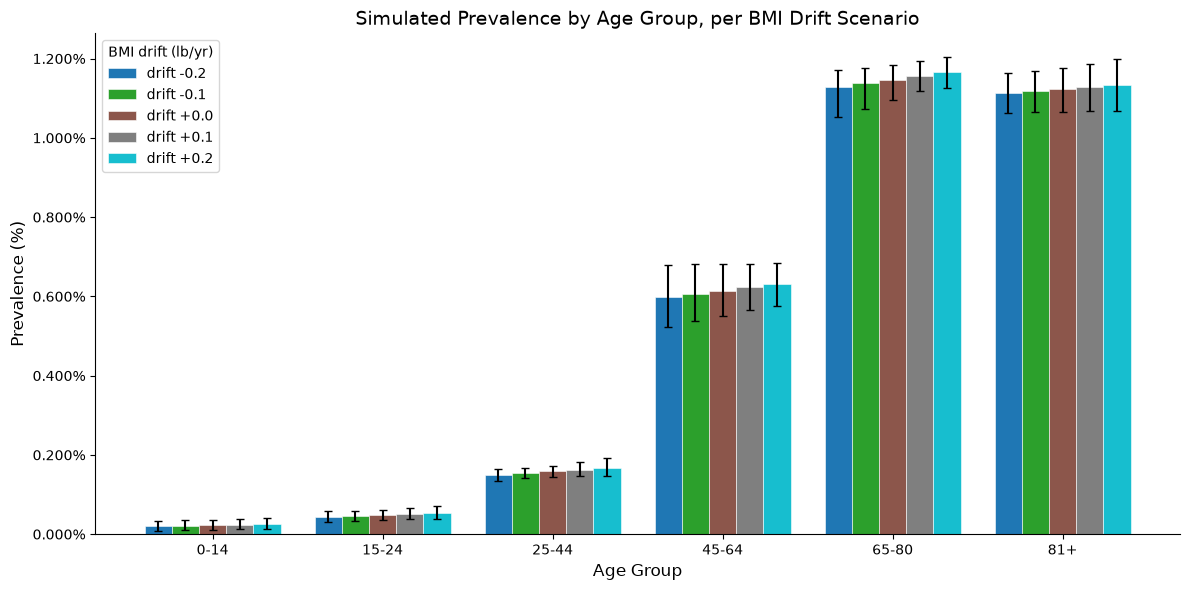

In [57]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")

plot_by_drift(
    sim_df=df,
    ylabel="Prevalence (%)",
    title="Simulated Prevalence by Age Group, per BMI Drift Scenario",
    out_path="Graphs/prev_by_age_group_by_drift.png",
)

## Annual Incidence Rate by Age Group: All 5 BMI Drift Scenarios (independent)

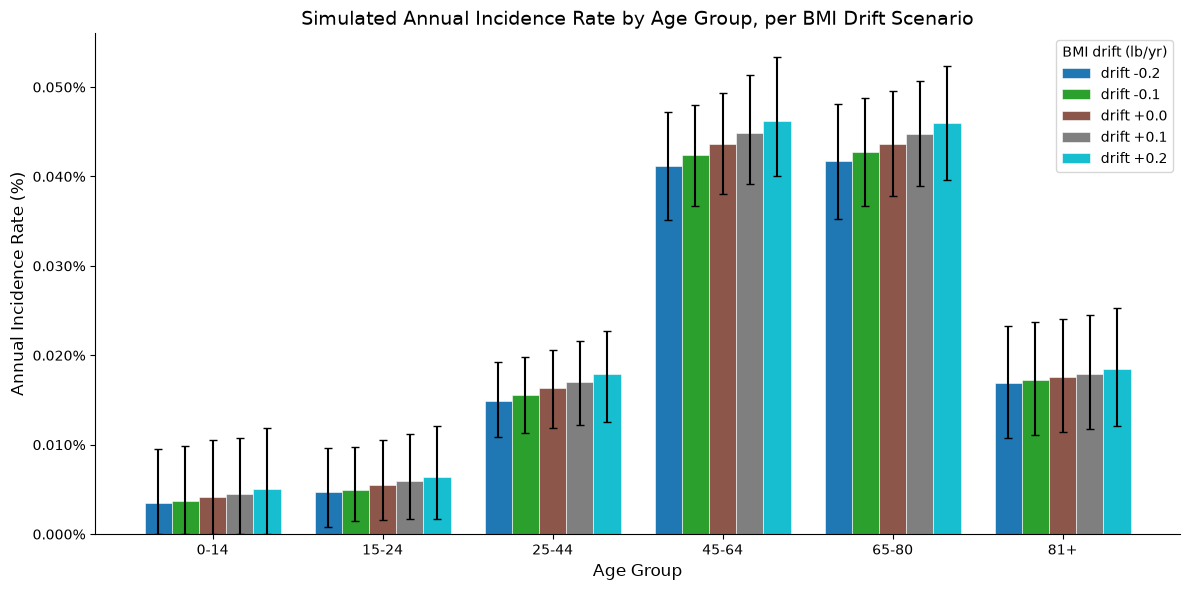

In [58]:
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")

plot_by_drift(
    sim_df=df_inci,
    ylabel="Annual Incidence Rate (%)",
    title="Simulated Annual Incidence Rate by Age Group, per BMI Drift Scenario",
    out_path="Graphs/inci_by_age_group_by_drift.png",
)

## Prevalence by Age Group: Zero-BMI-Drift Scenario vs GBD 2023 (with 95% CI)

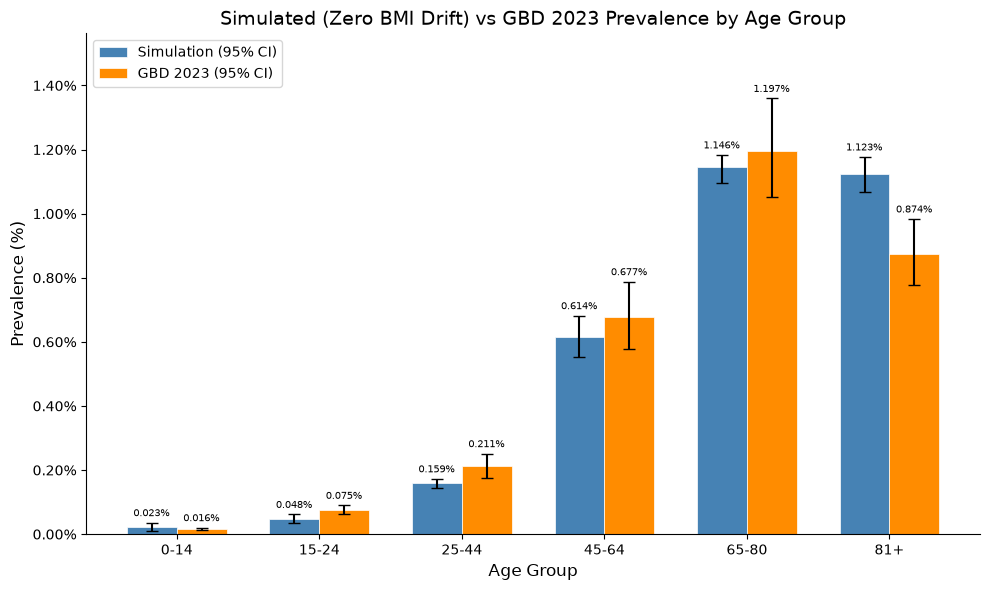

In [59]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")
df_zero_drift = df[df["bmi_drift"] == 0.0]

plot_sim_vs_gbd(
    sim_df=df_zero_drift,
    gbd_bands=gbd_prev_bands,
    ylabel="Prevalence (%)",
    title="Simulated (Zero BMI Drift) vs GBD 2023 Prevalence by Age Group",
    out_path="Graphs/prev_by_age_group_zero_drift_vs_gbd.png",
    sim_color="steelblue",
)

## Annual Incidence Rate by Age Group: Zero-BMI-Drift Scenario vs GBD 2023 (with 95% CI)

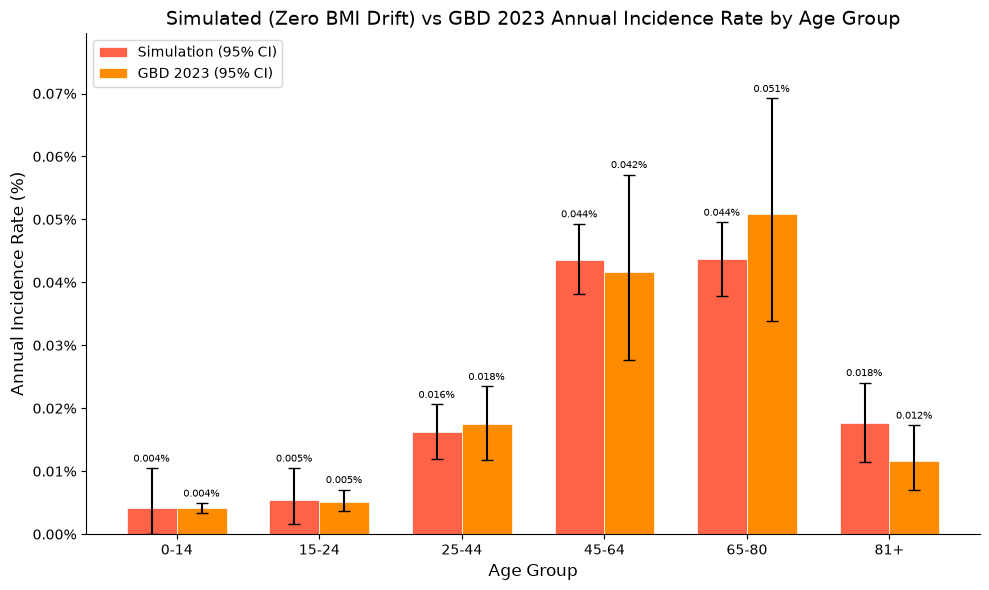

In [60]:
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")
df_inci_zero_drift = df_inci[df_inci["bmi_drift"] == 0.0]

plot_sim_vs_gbd(
    sim_df=df_inci_zero_drift,
    gbd_bands=gbd_inci_bands,
    ylabel="Annual Incidence Rate (%)",
    title="Simulated (Zero BMI Drift) vs GBD 2023 Annual Incidence Rate by Age Group",
    out_path="Graphs/inci_by_age_group_zero_drift_vs_gbd.png",
    sim_color="tomato",
)

## Prevalence by Age Group: Obese vs Non-Obese (disjoint subsets, with 95% CI)

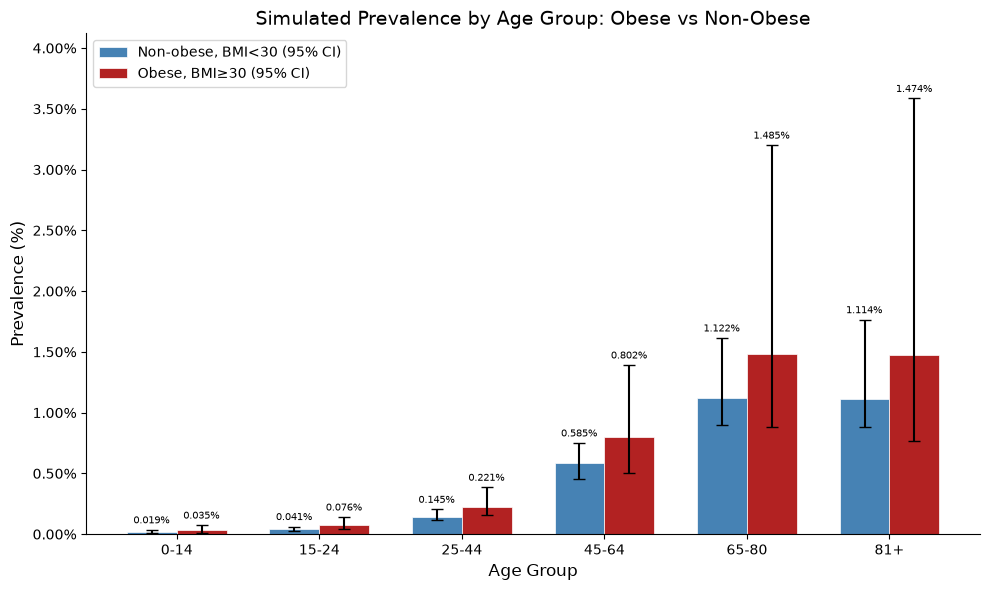

In [61]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")

plot_obese_vs_nonobese(
    sim_df=df,
    ylabel="Prevalence (%)",
    title="Simulated Prevalence by Age Group: Obese vs Non-Obese",
    out_path="Graphs/prev_by_age_group_obese_vs_nonobese.png",
    color_nonobese="steelblue",
)

## Annual Incidence Rate by Age Group: Obese vs Non-Obese (disjoint subsets, with 95% CI)

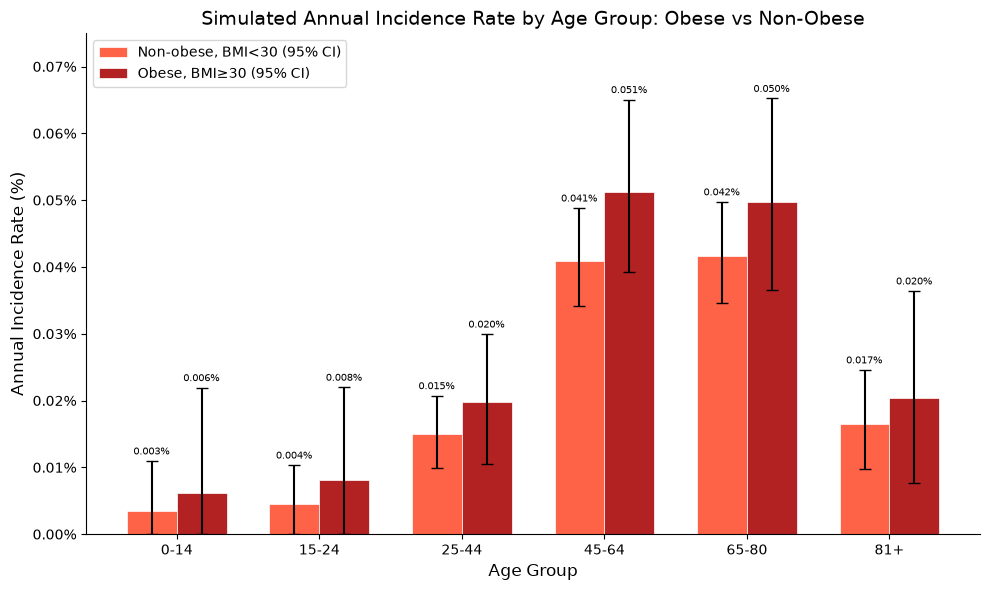

In [62]:
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")

plot_obese_vs_nonobese(
    sim_df=df_inci,
    ylabel="Annual Incidence Rate (%)",
    title="Simulated Annual Incidence Rate by Age Group: Obese vs Non-Obese",
    out_path="Graphs/inci_by_age_group_obese_vs_nonobese.png",
    color_nonobese="tomato",
)

## Prevalence Over Time, by Age Group -- one chart per BMI Drift Scenario

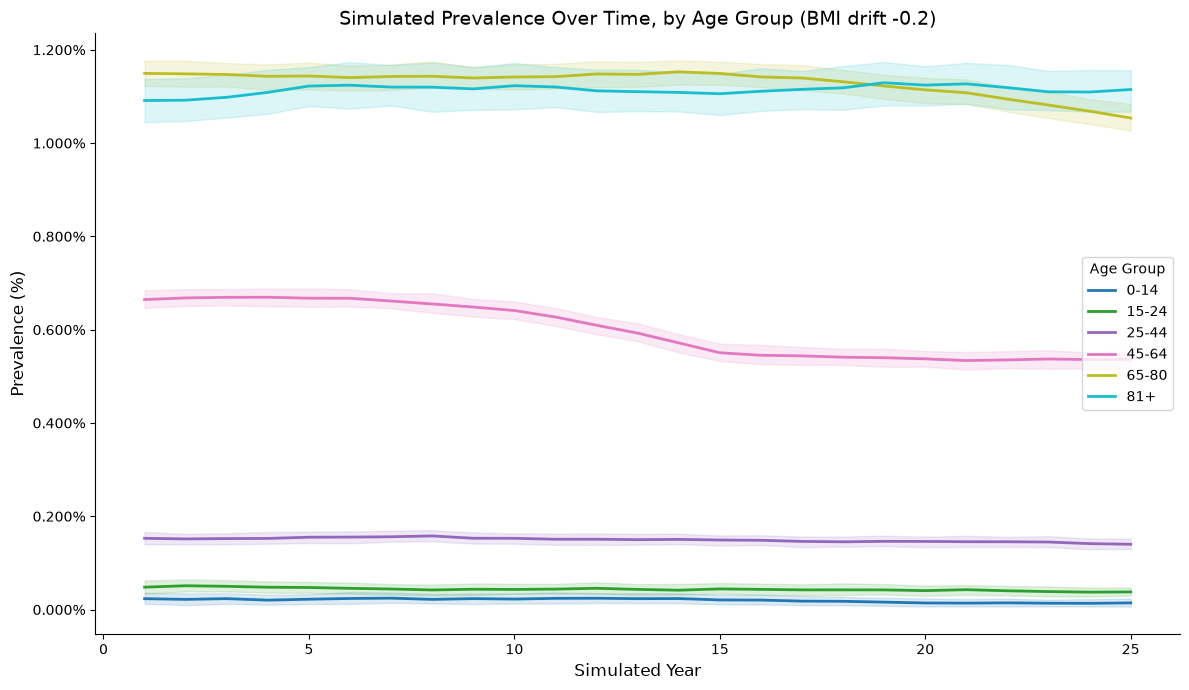

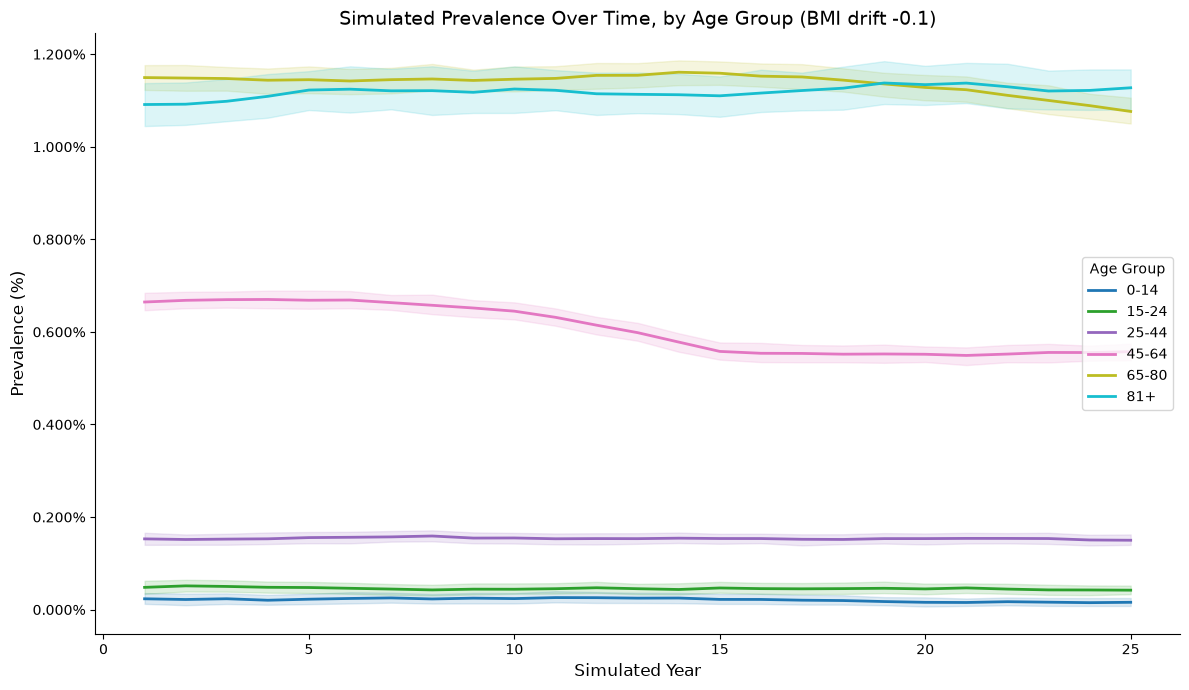

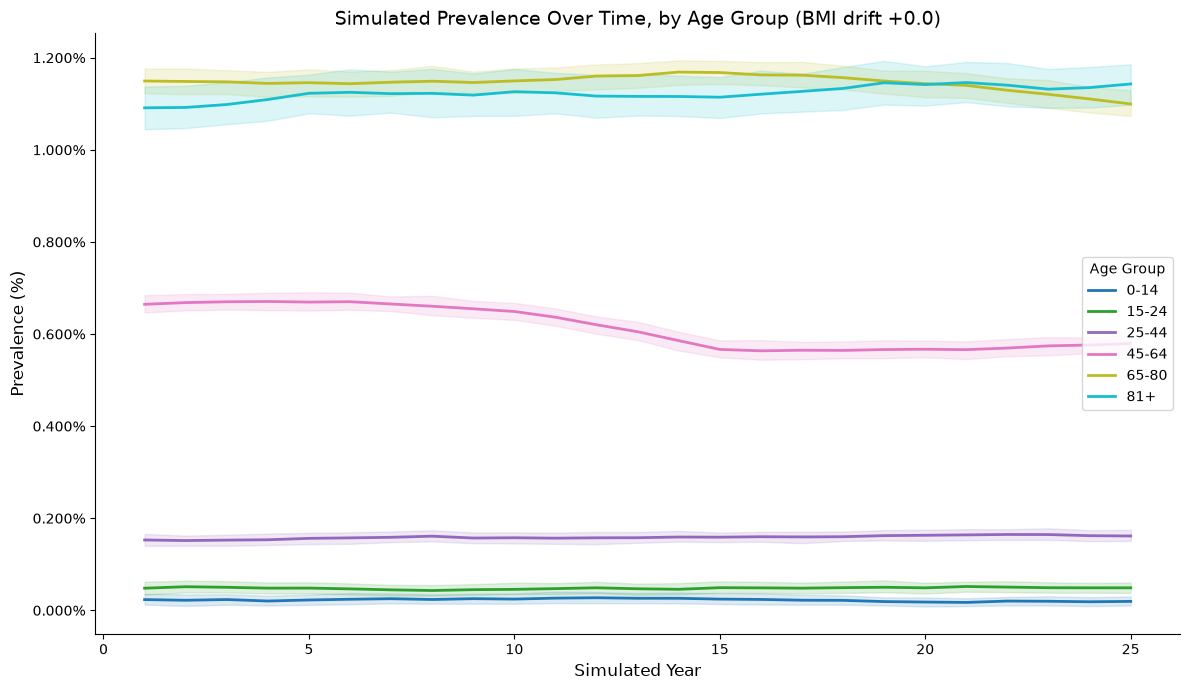

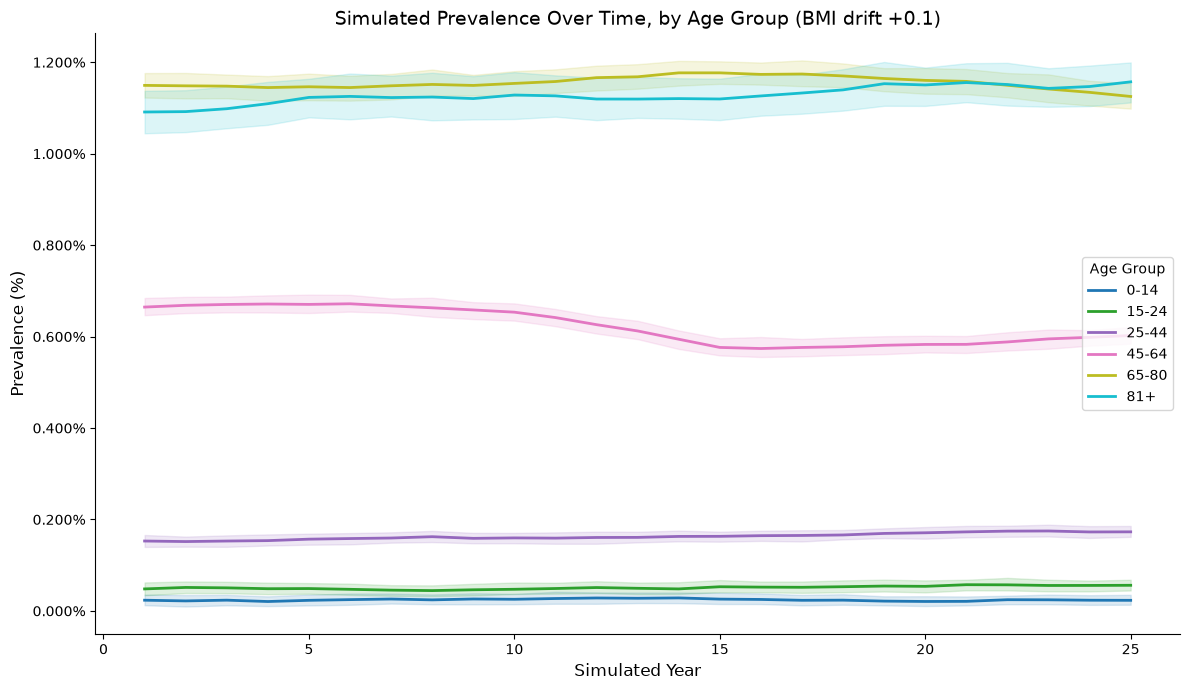

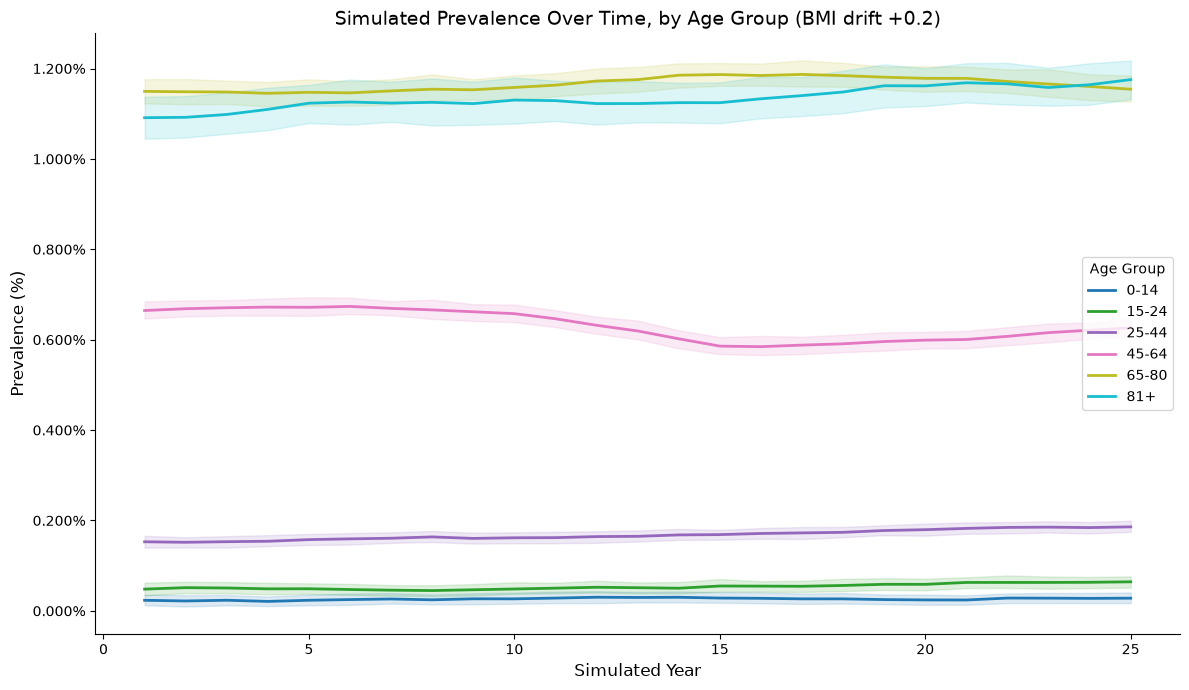

In [63]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")

for drift in sorted(df["bmi_drift"].unique()):
    sub = df[df["bmi_drift"] == drift]
    plot_over_time(
        sim_df=sub,
        ylabel="Prevalence (%)",
        title=f"Simulated Prevalence Over Time, by Age Group (BMI drift {drift:+.1f})",
        out_path=f"Graphs/prev_over_time_by_age_group_drift_{drift:+.1f}.png",
    )

## Annual Incidence Rate Over Time, by Age Group -- one chart per BMI Drift Scenario

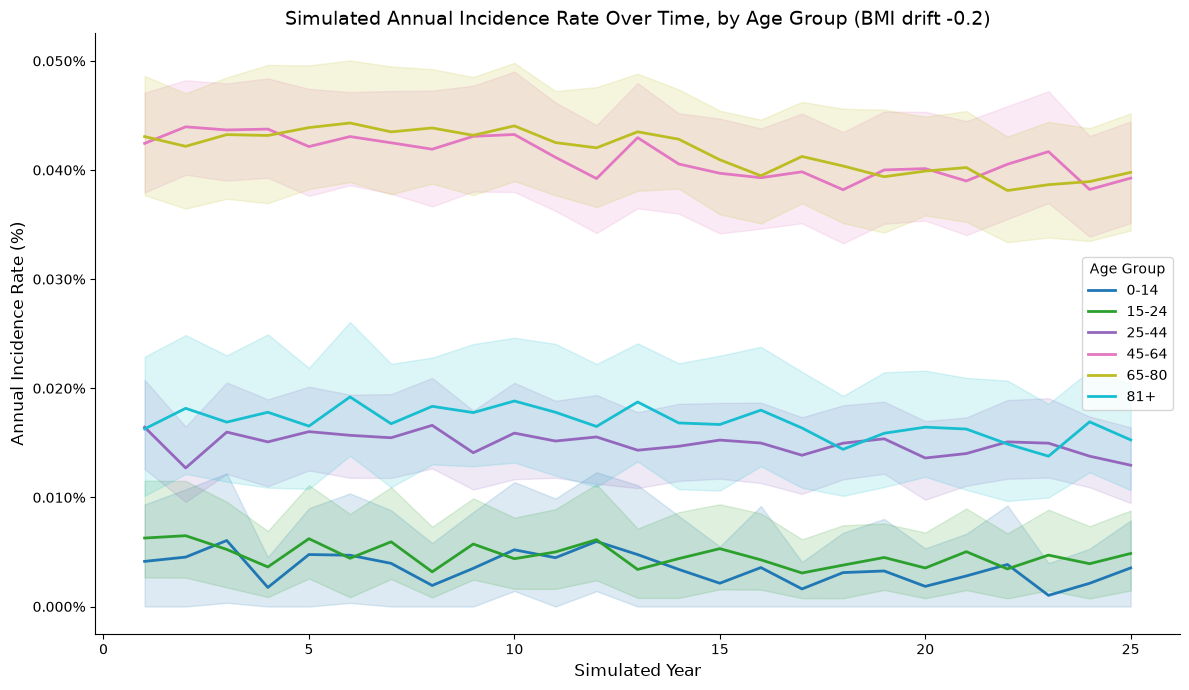

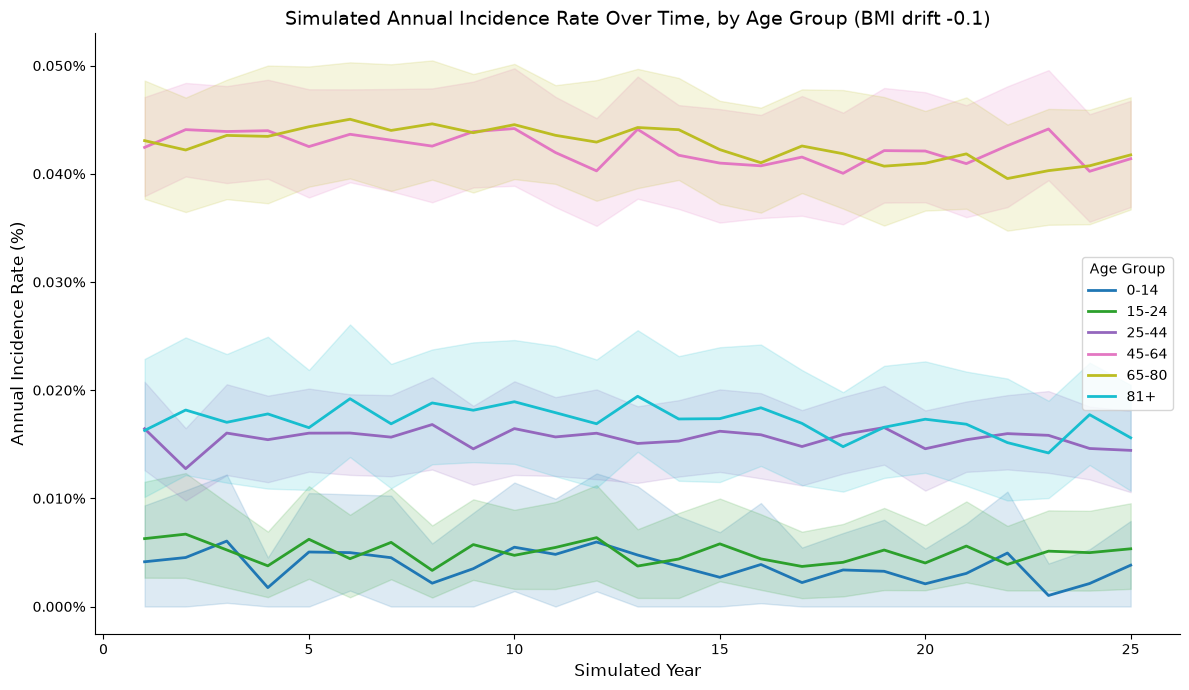

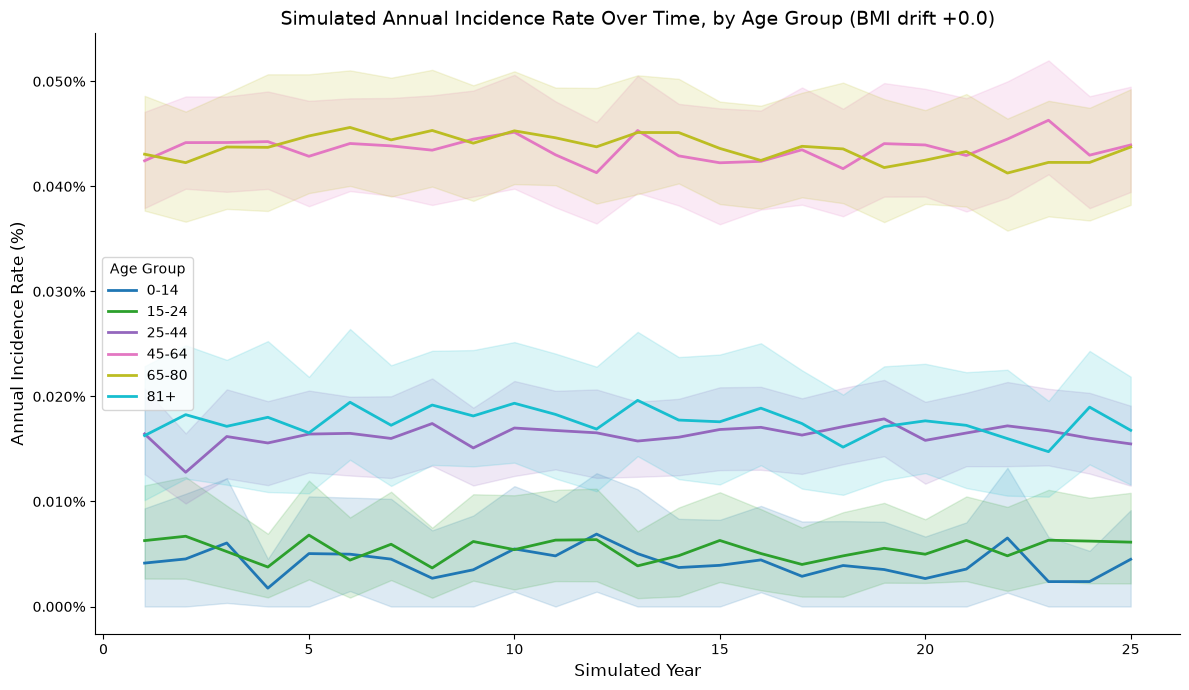

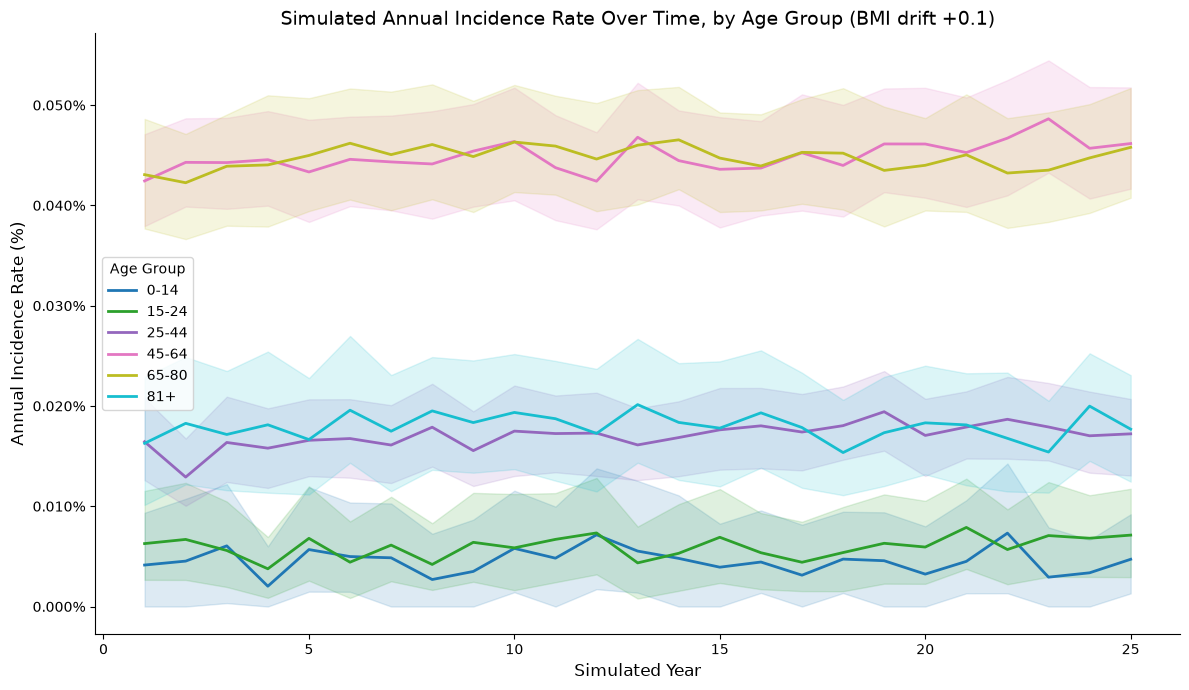

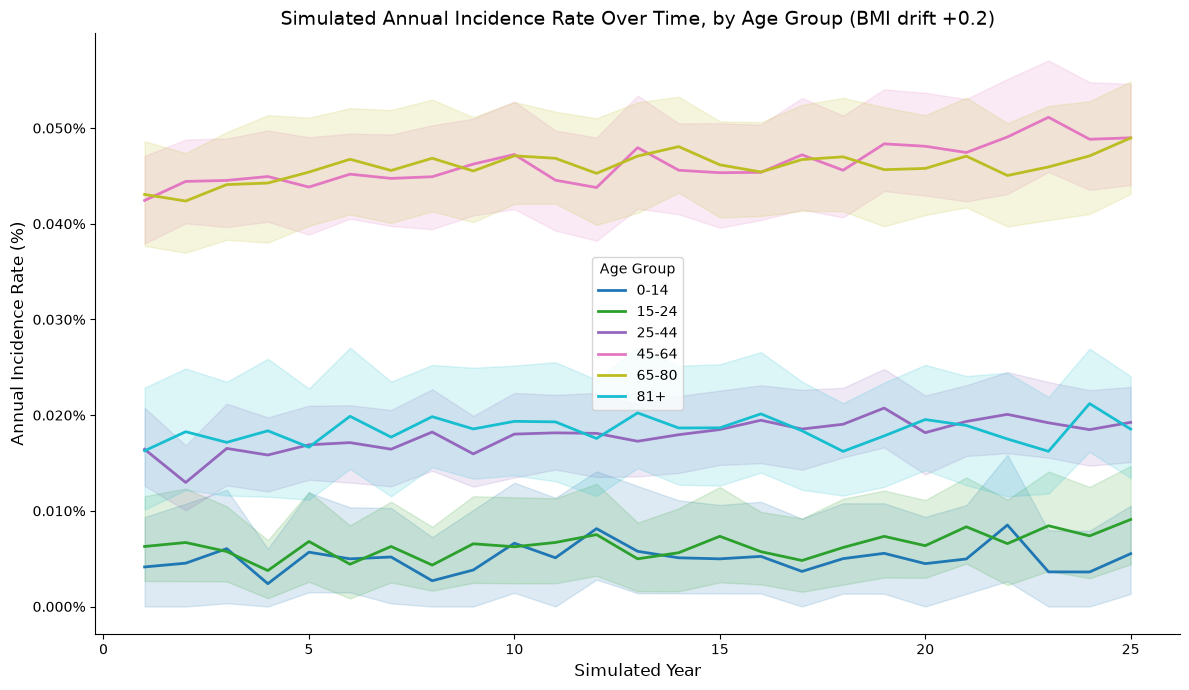

In [64]:
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")

for drift in sorted(df_inci["bmi_drift"].unique()):
    sub = df_inci[df_inci["bmi_drift"] == drift]
    plot_over_time(
        sim_df=sub,
        ylabel="Annual Incidence Rate (%)",
        title=f"Simulated Annual Incidence Rate Over Time, by Age Group (BMI drift {drift:+.1f})",
        out_path=f"Graphs/inci_over_time_by_age_group_drift_{drift:+.1f}.png",
    )

## Prevalence Over Time with Best-Fit Lines + Fit Summary Tables -- one per BMI Drift Scenario

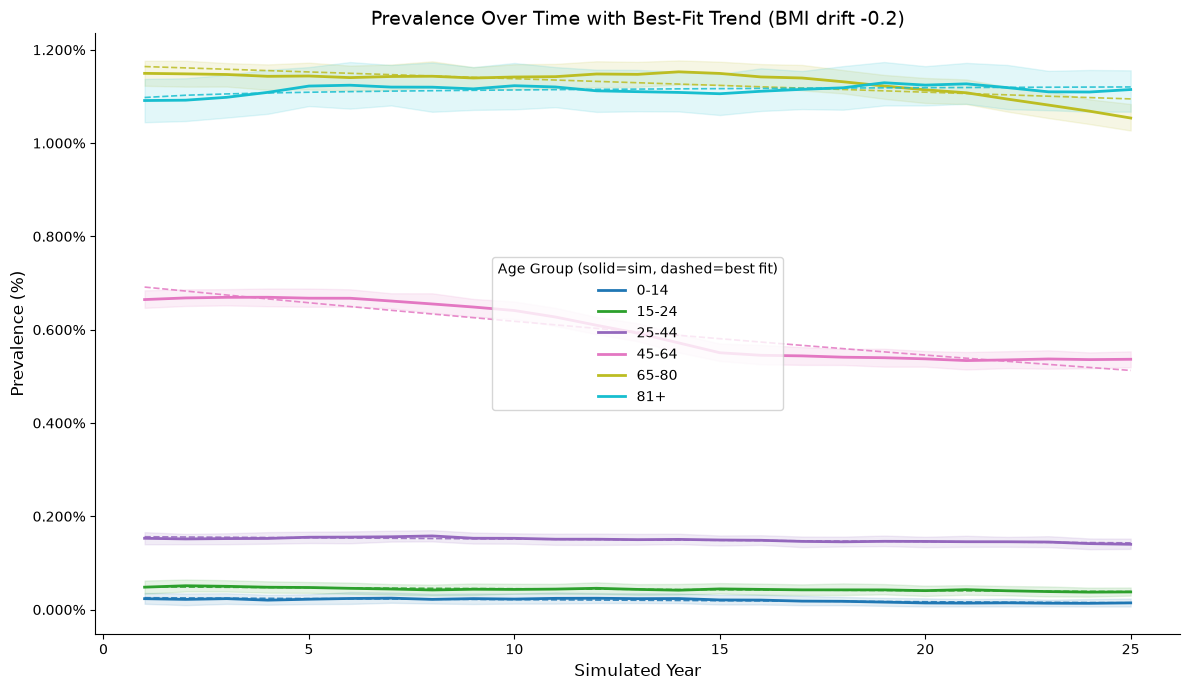

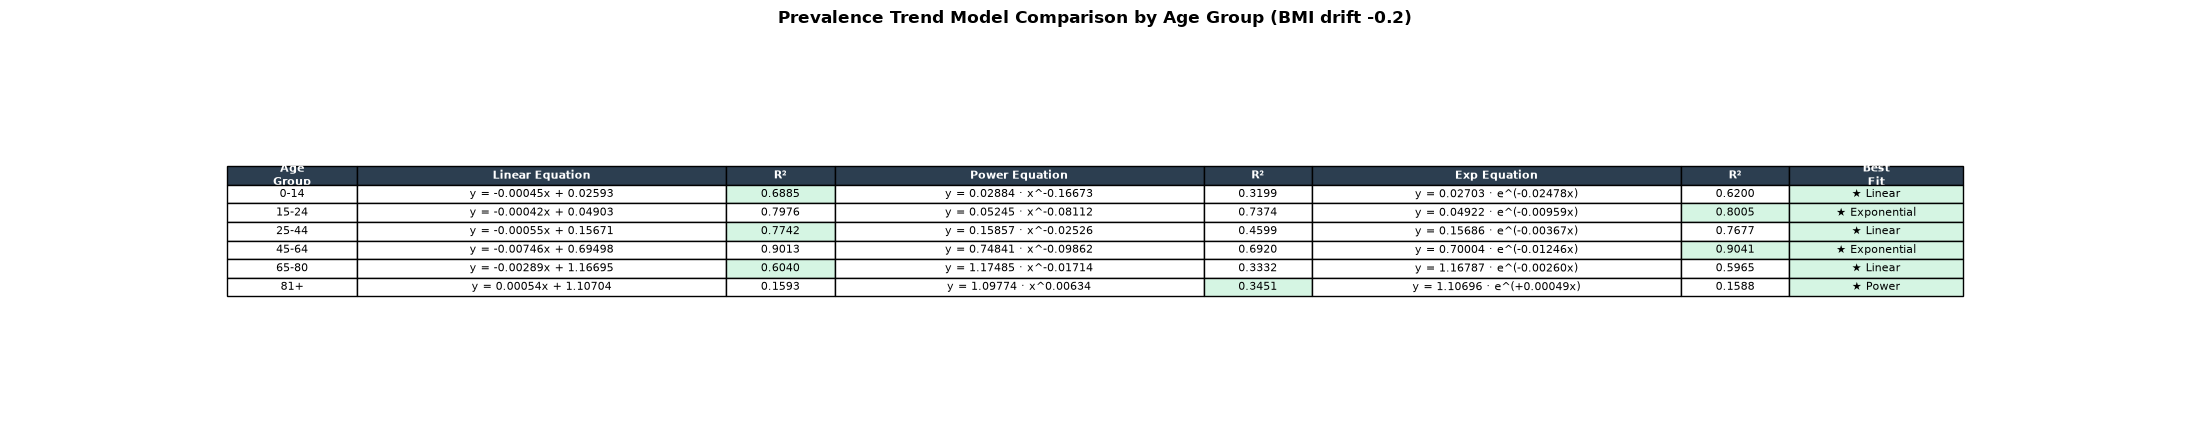

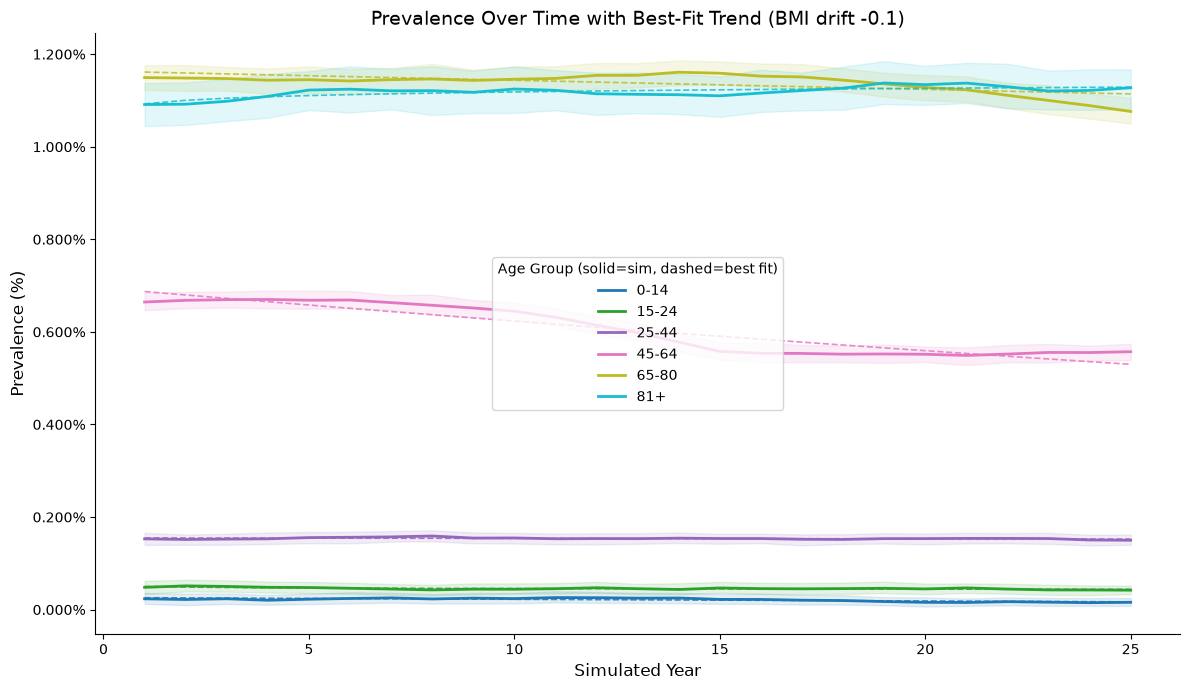

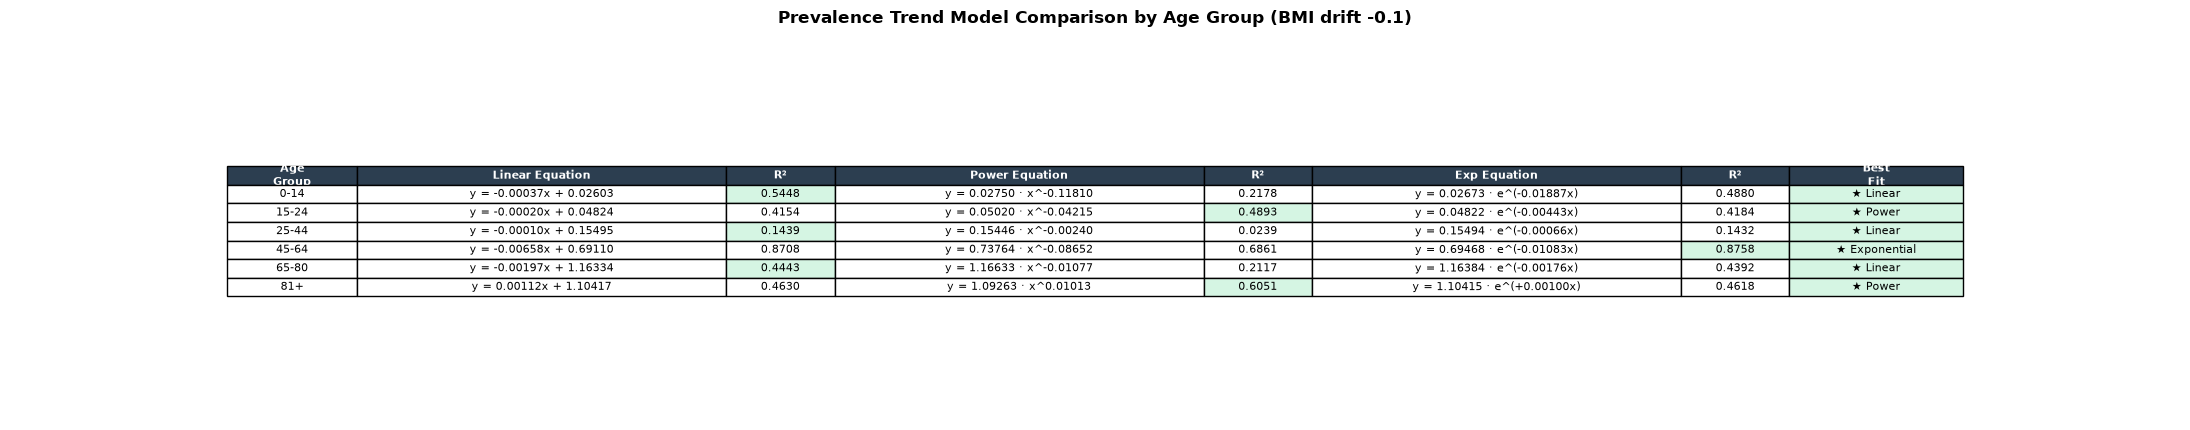

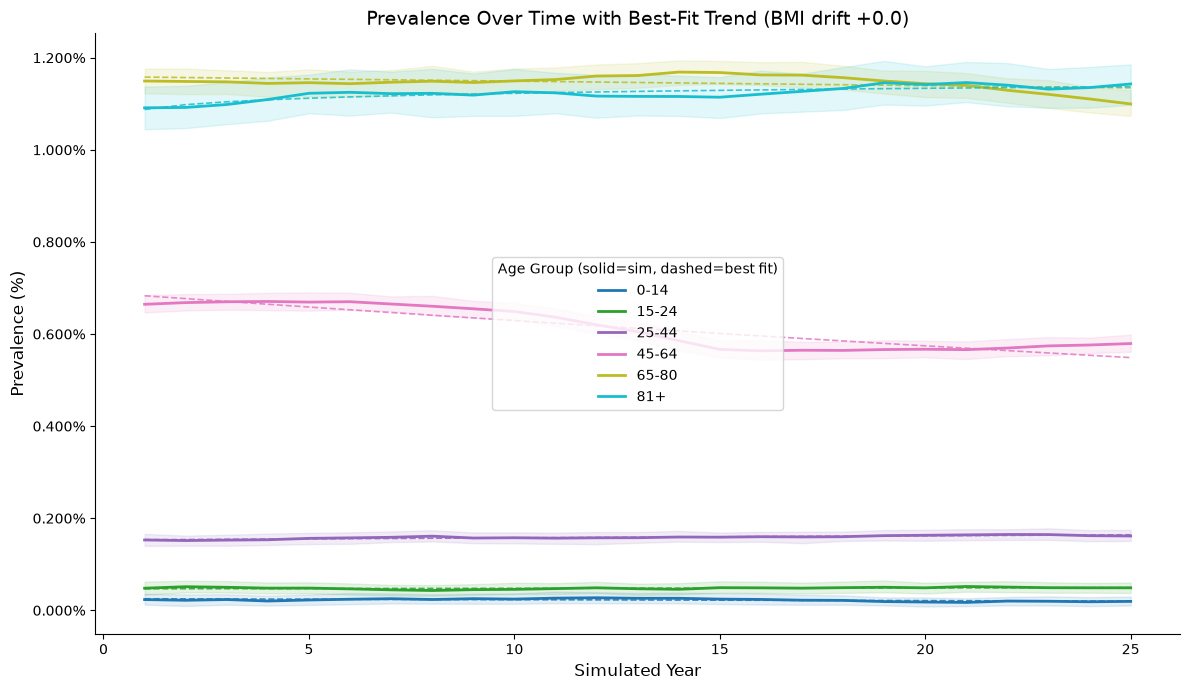

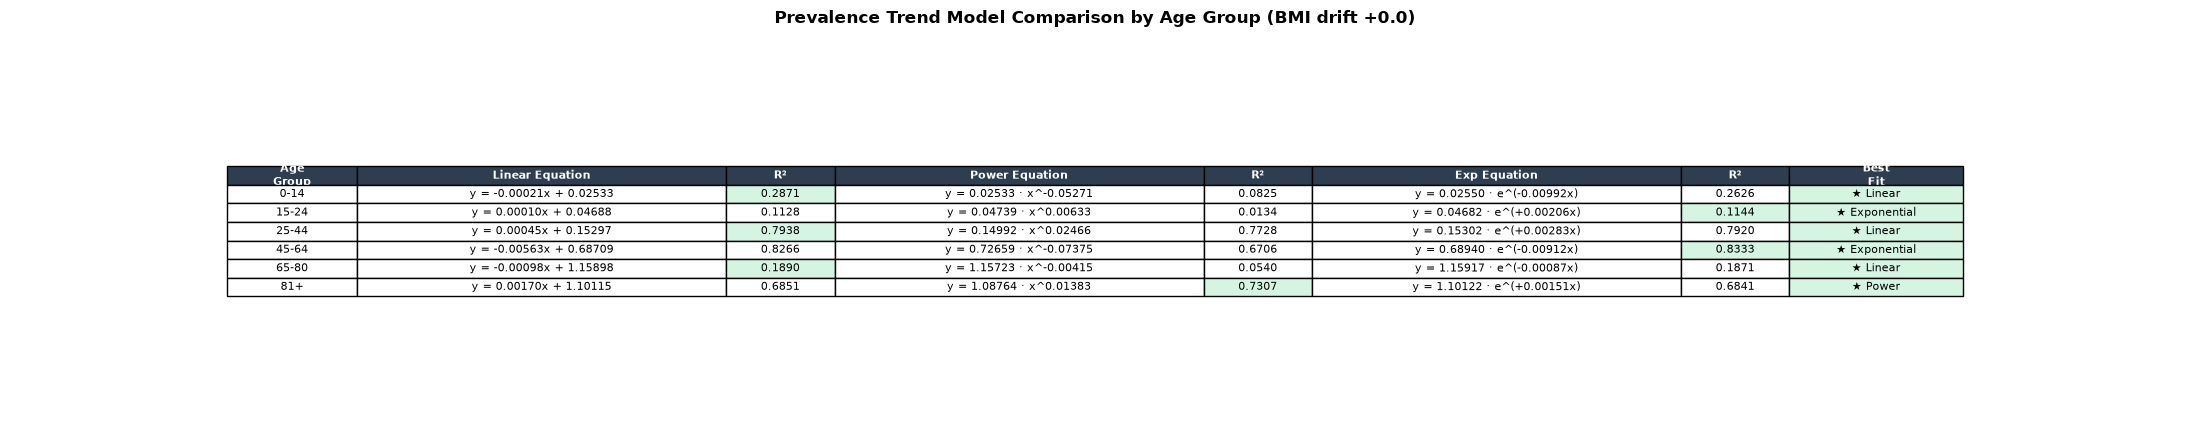

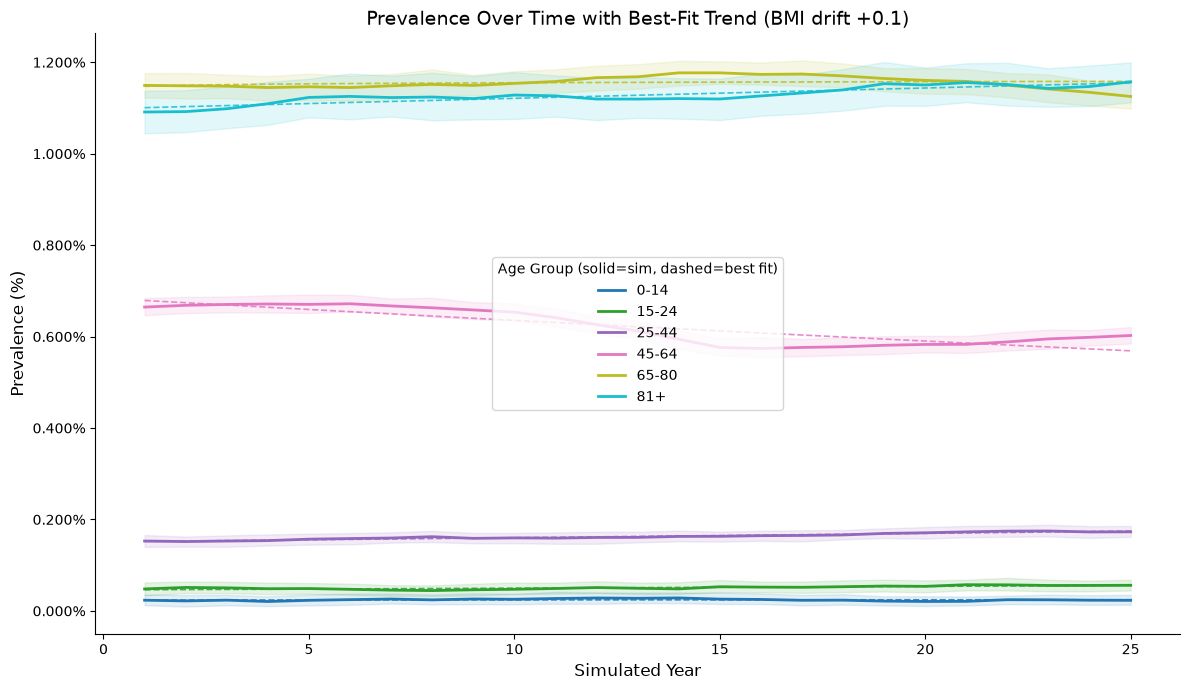

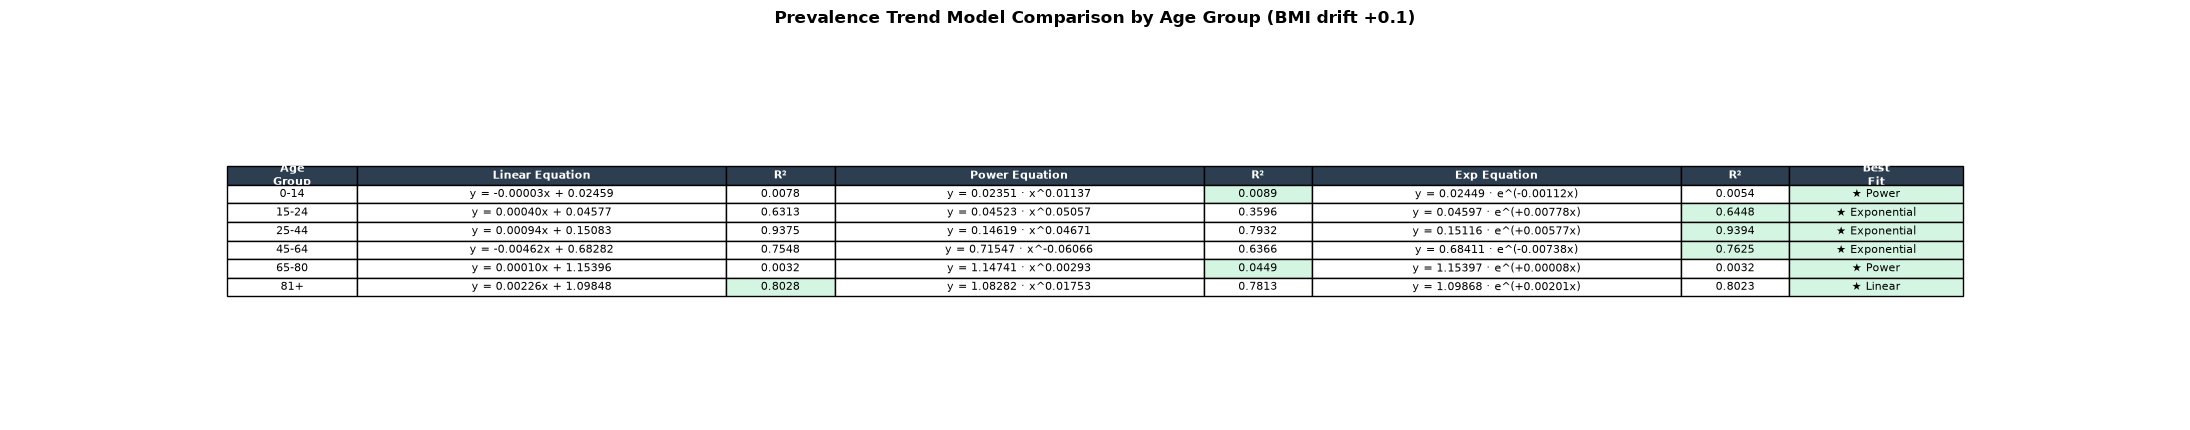

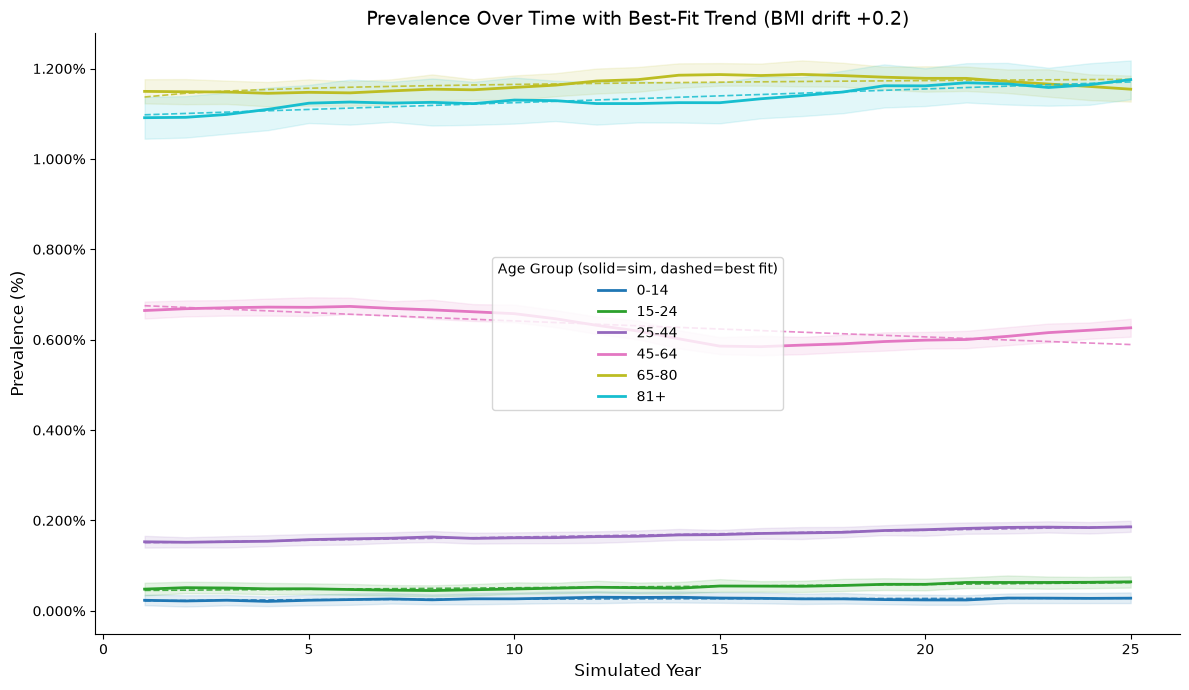

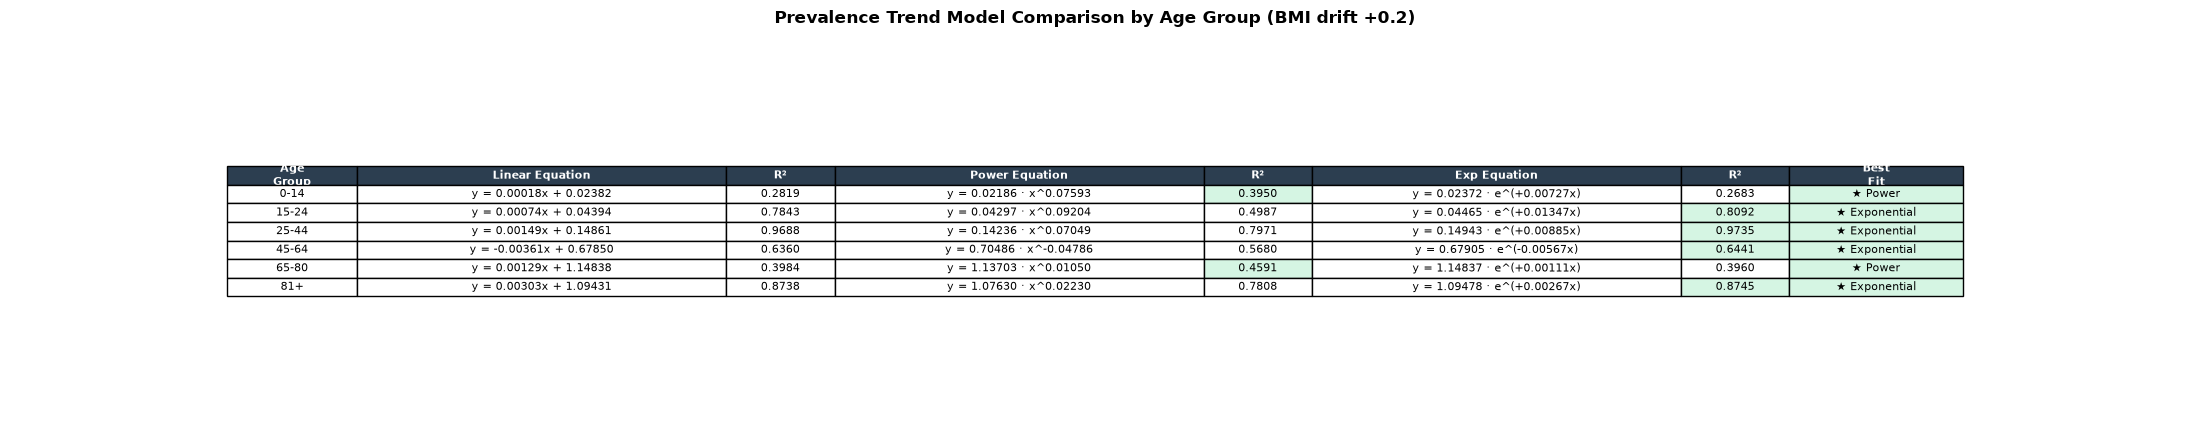

In [65]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")

for drift in sorted(df["bmi_drift"].unique()):
    sub = df[df["bmi_drift"] == drift]
    plot_over_time_with_fits(
        sim_df=sub,
        ylabel="Prevalence (%)",
        title=f"Prevalence Over Time with Best-Fit Trend (BMI drift {drift:+.1f})",
        out_path=f"Graphs/prev_over_time_fits_drift_{drift:+.1f}.png",
    )
    plot_fit_table(
        sim_df=sub,
        title=f"Prevalence Trend Model Comparison by Age Group (BMI drift {drift:+.1f})",
        out_path=f"Graphs/prev_fit_table_drift_{drift:+.1f}.png",
    )

## Annual Incidence Rate Over Time with Best-Fit Lines + Fit Summary Tables -- one per BMI Drift Scenario

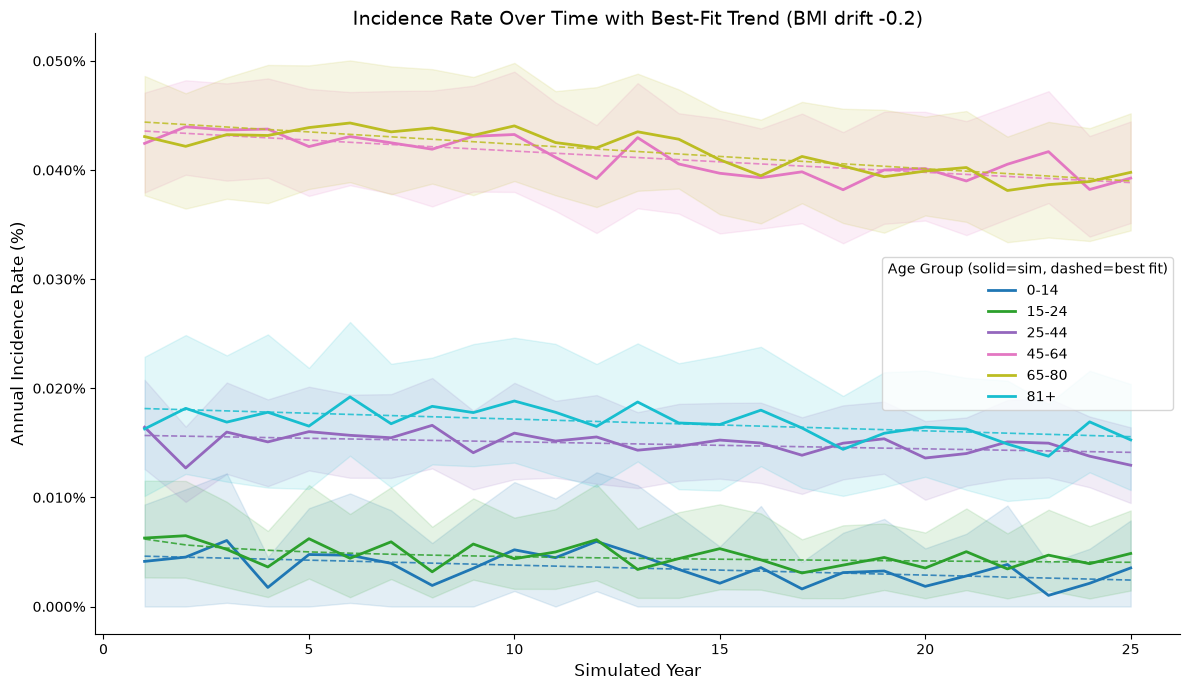

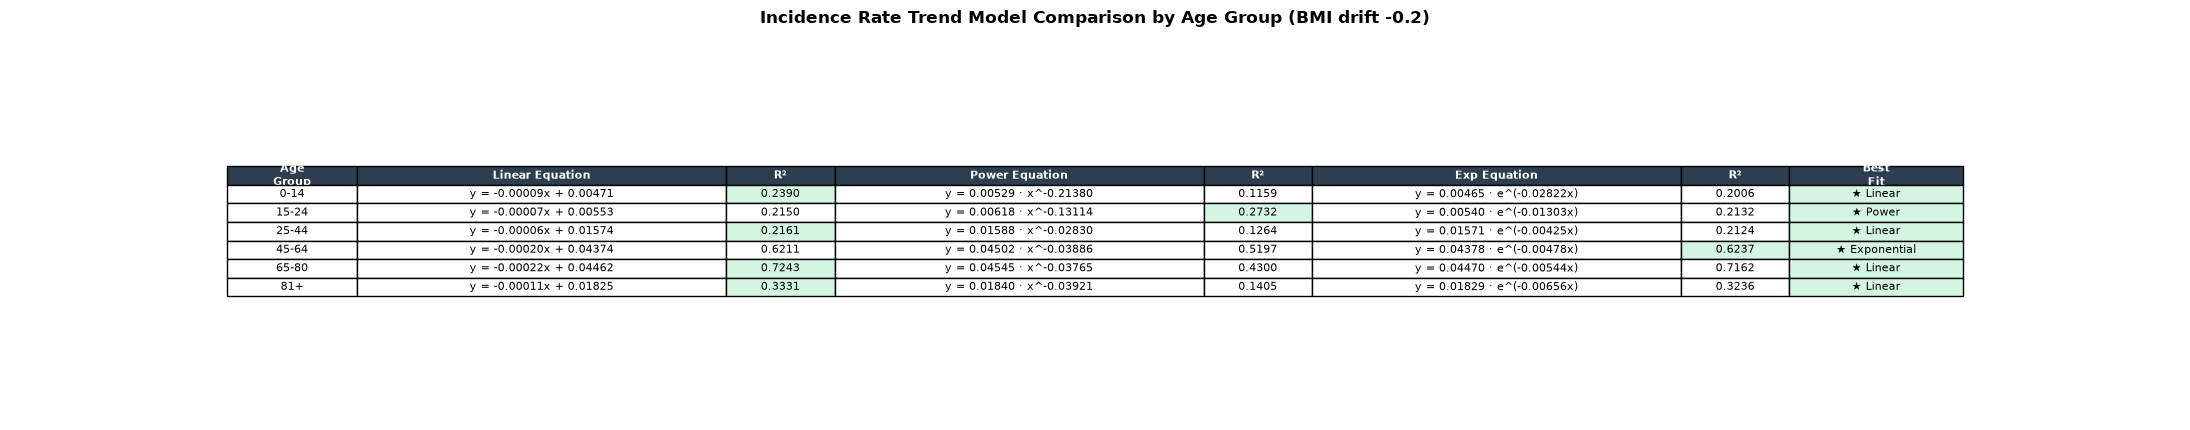

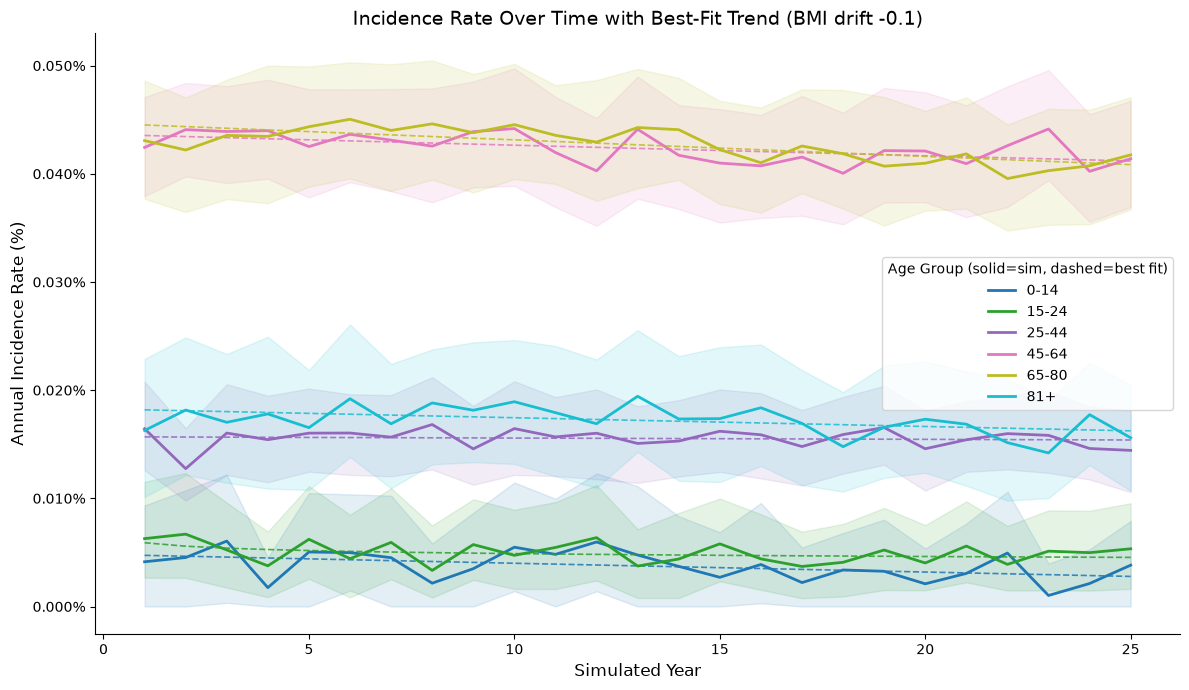

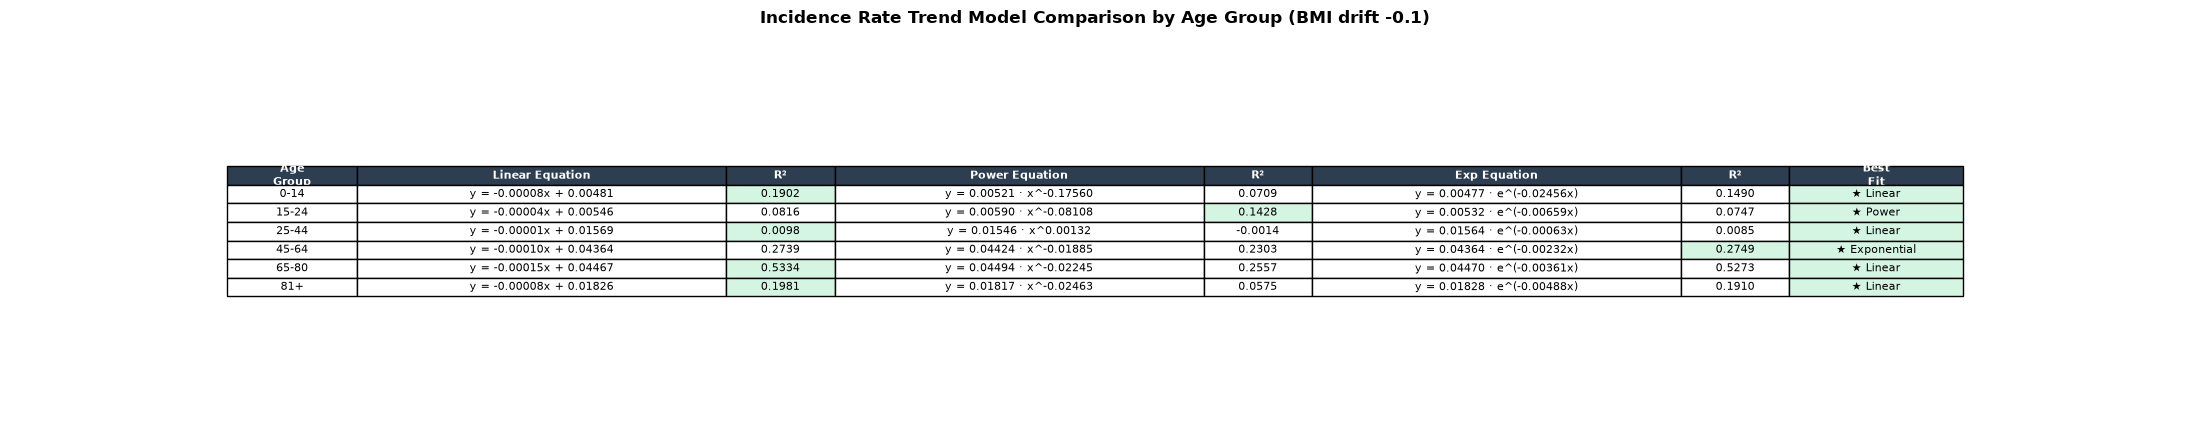

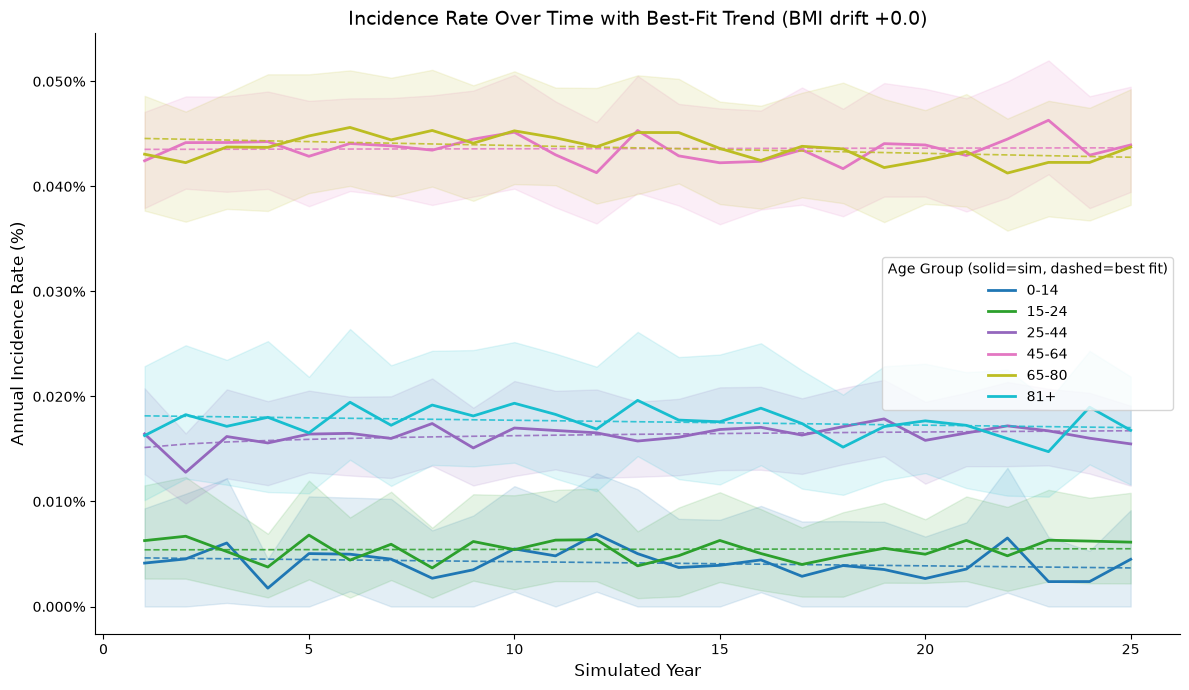

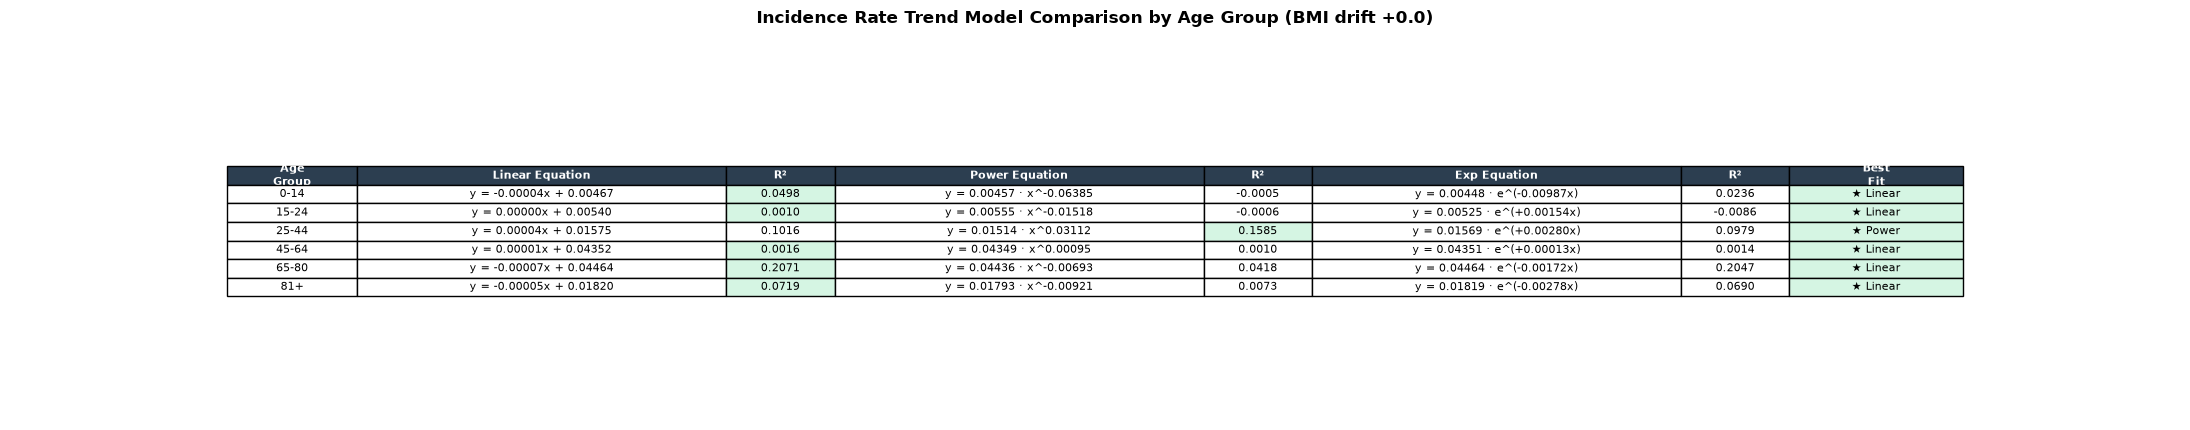

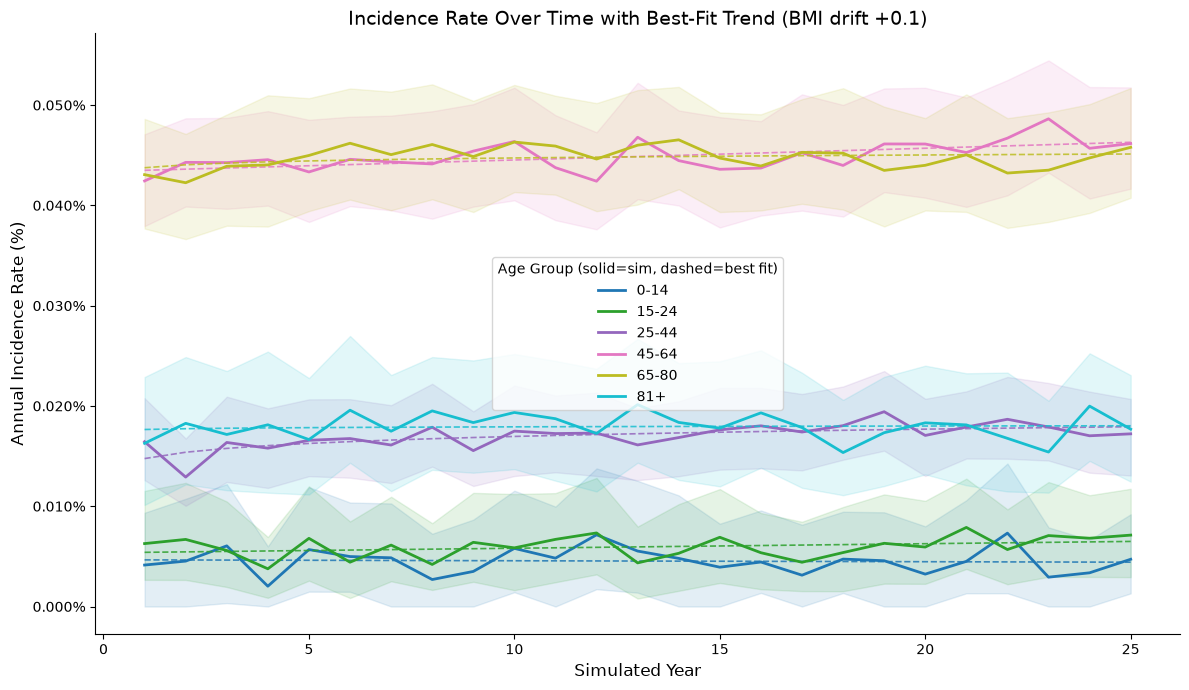

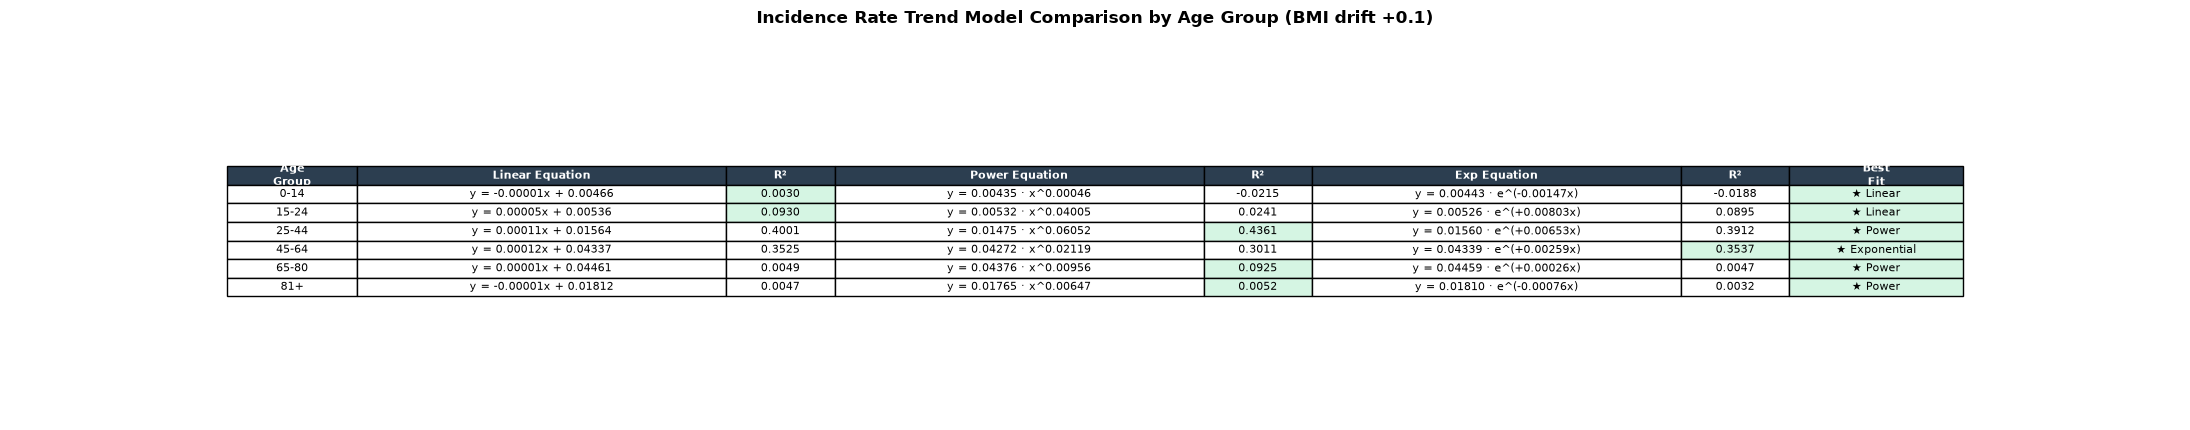

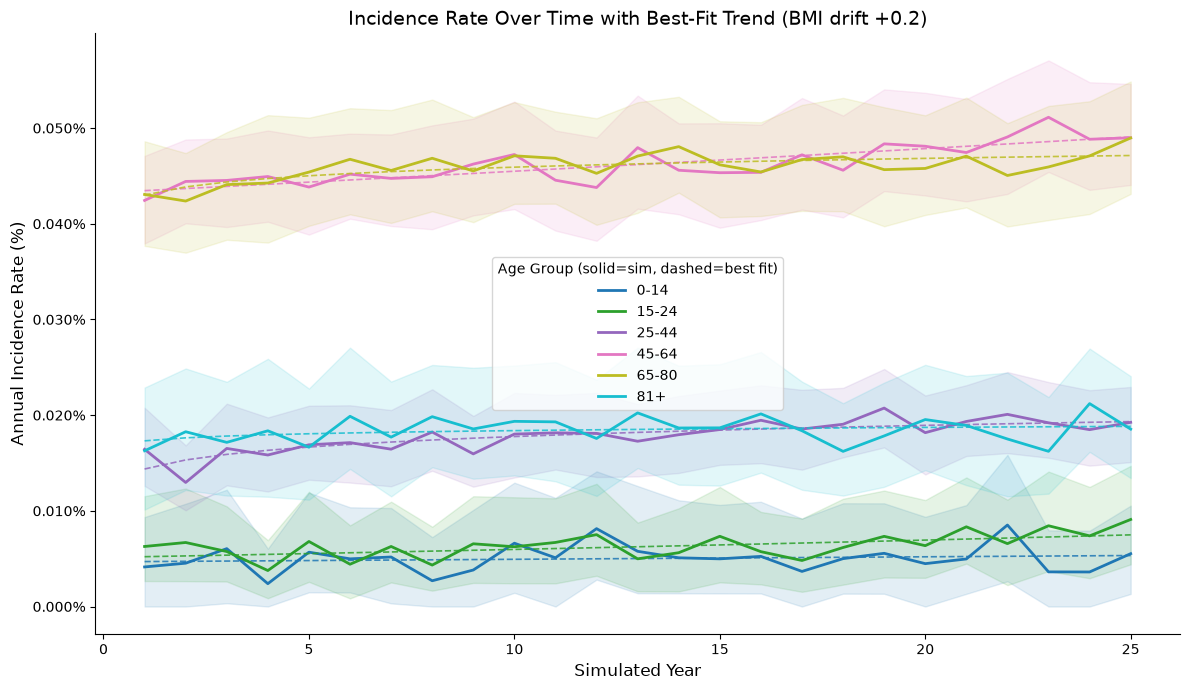

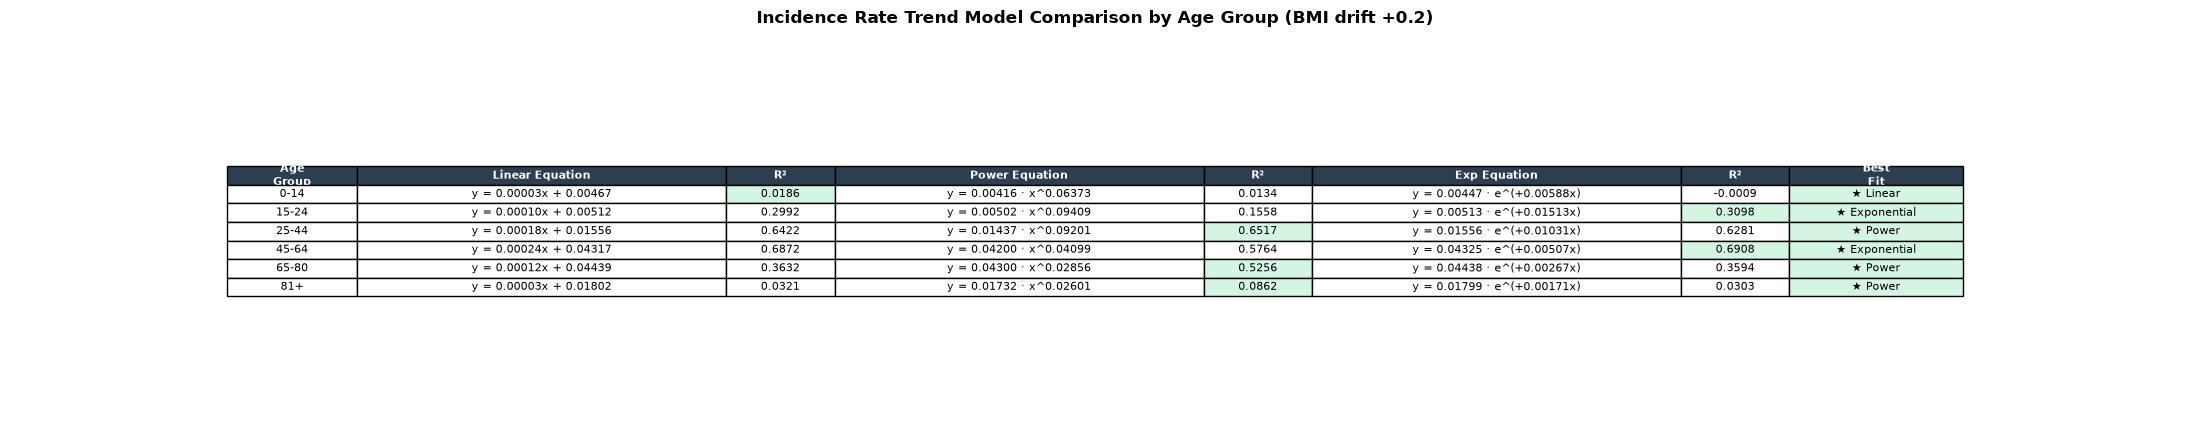

In [66]:
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")

for drift in sorted(df_inci["bmi_drift"].unique()):
    sub = df_inci[df_inci["bmi_drift"] == drift]
    plot_over_time_with_fits(
        sim_df=sub,
        ylabel="Annual Incidence Rate (%)",
        title=f"Incidence Rate Over Time with Best-Fit Trend (BMI drift {drift:+.1f})",
        out_path=f"Graphs/inci_over_time_fits_drift_{drift:+.1f}.png",
    )
    plot_fit_table(
        sim_df=sub,
        title=f"Incidence Rate Trend Model Comparison by Age Group (BMI drift {drift:+.1f})",
        out_path=f"Graphs/inci_fit_table_drift_{drift:+.1f}.png",
    )

## Population-Attributable Fraction (PAF) of Obesity on RA, by Age Group and BMI Drift Scenario

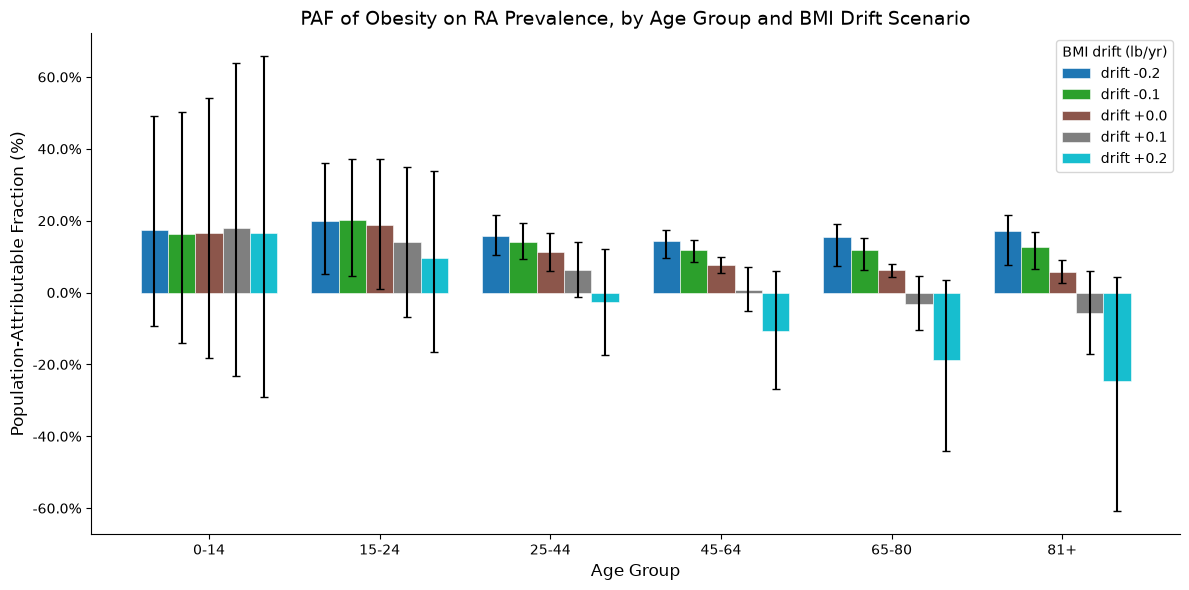

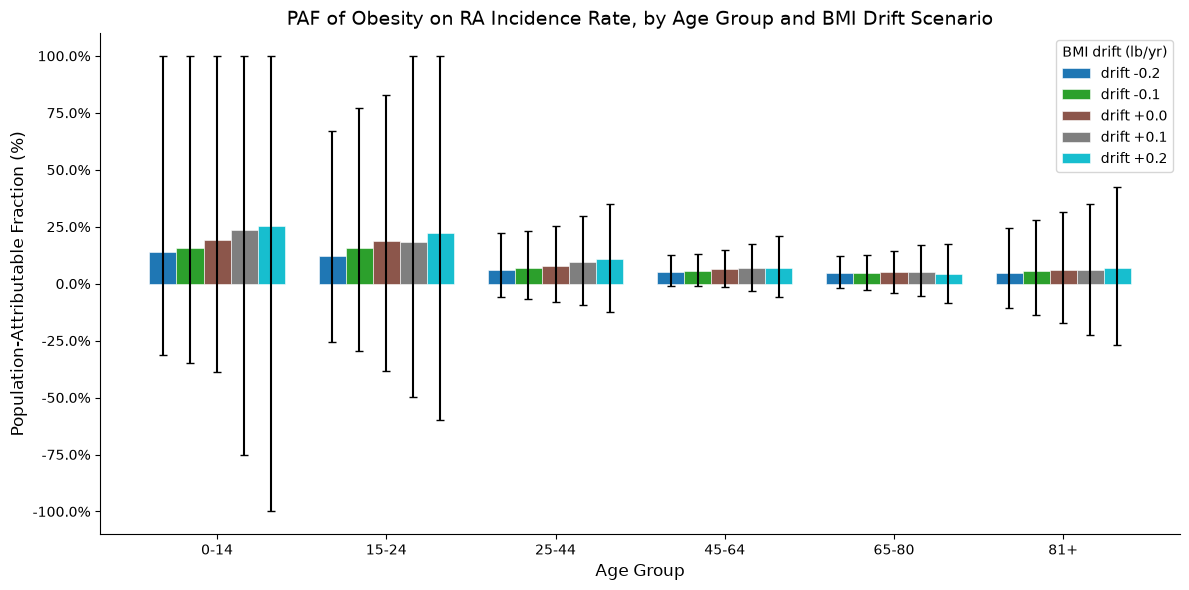

In [67]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")

plot_paf_by_drift(
    sim_df=df,
    title="PAF of Obesity on RA Prevalence, by Age Group and BMI Drift Scenario",
    out_path="Graphs/prev_paf_by_age_group_by_drift.png",
)

plot_paf_by_drift(
    sim_df=df_inci,
    title="PAF of Obesity on RA Incidence Rate, by Age Group and BMI Drift Scenario",
    out_path="Graphs/inci_paf_by_age_group_by_drift.png",
)

## Scenario Comparison: Mean Rate Across All Simulated Years, by Age Group and BMI Drift Scenario

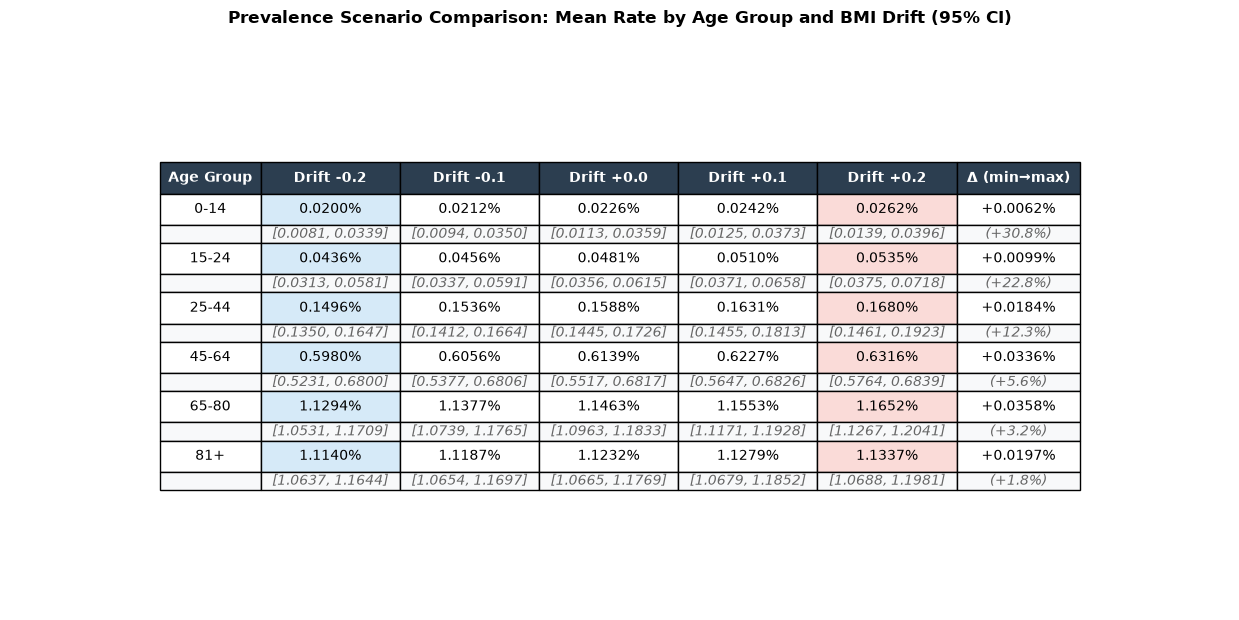

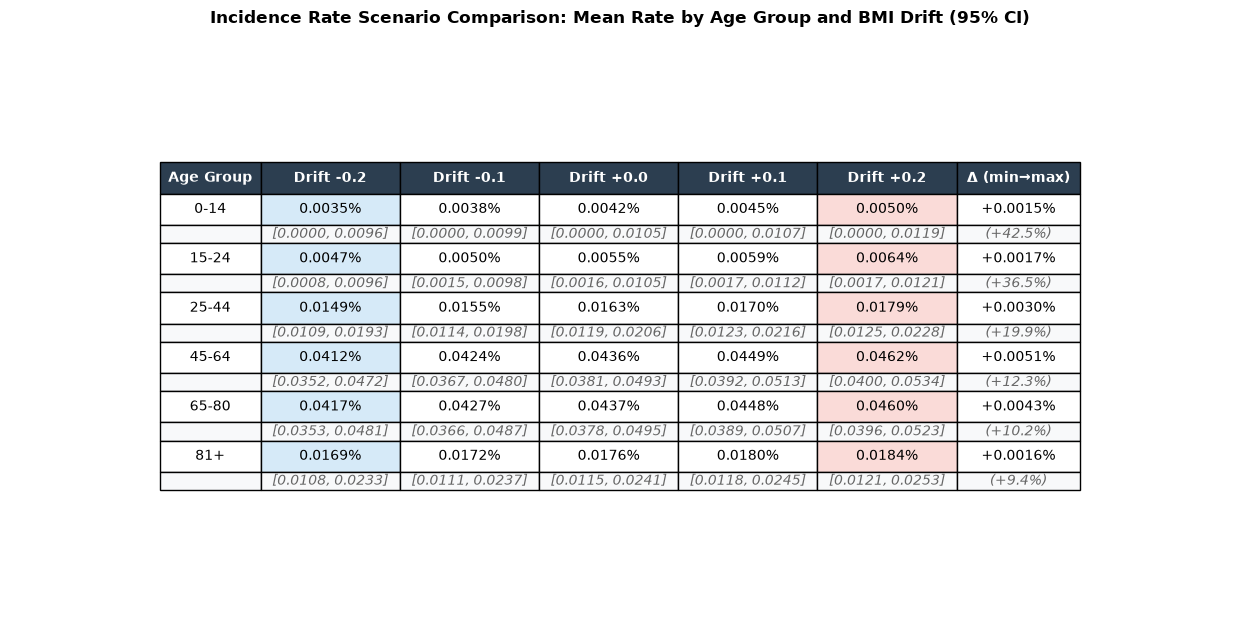

In [68]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")

plot_scenario_table(
    sim_df=df,
    metric_label="Prevalence (%)",
    title="Prevalence Scenario Comparison: Mean Rate by Age Group and BMI Drift (95% CI)",
    out_path="Graphs/prev_scenario_comparison_table.png",
)

plot_scenario_table(
    sim_df=df_inci,
    metric_label="Annual Incidence Rate (%)",
    title="Incidence Rate Scenario Comparison: Mean Rate by Age Group and BMI Drift (95% CI)",
    out_path="Graphs/inci_scenario_comparison_table.png",
)

## Adjusted PAF of Obesity on RA (Baseline RR Fixed, Obesity Prevalence Scaled)

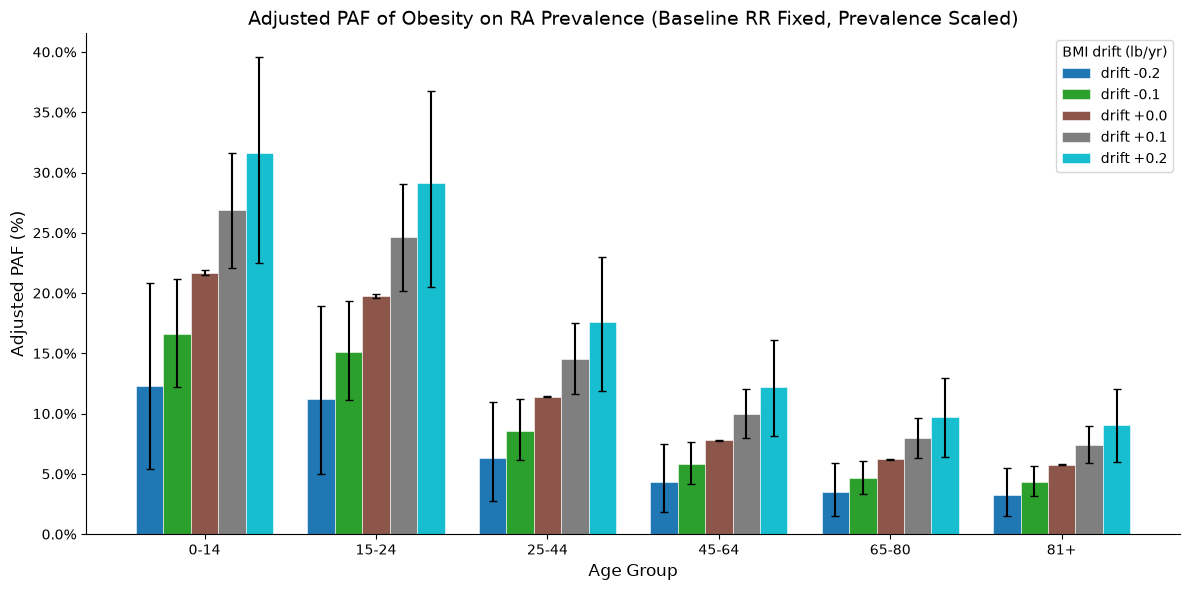

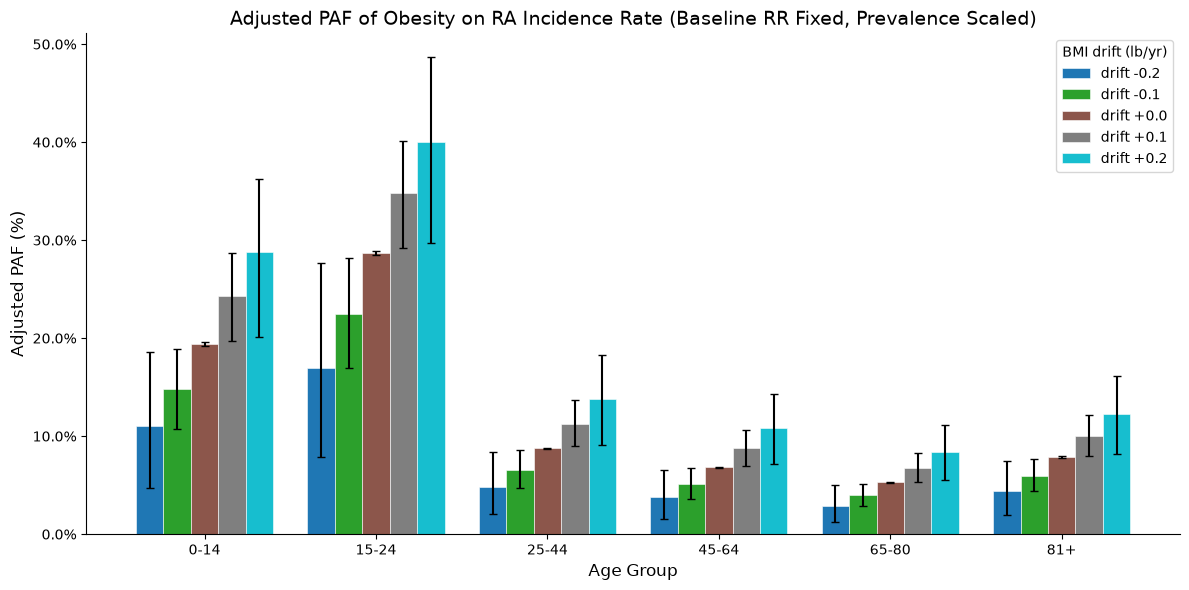

: 

In [ ]:
df = pd.read_csv("Data/prev_longitudinal_by_cohort.csv")
df_inci = pd.read_csv("Data/inci_longitudinal_by_cohort.csv")

plot_paf_adjusted_by_drift(
    sim_df=df,
    title="Adjusted PAF of Obesity on RA Prevalence (Baseline RR Fixed, Prevalence Scaled)",
    out_path="Graphs/prev_paf_adjusted_by_drift.png",
)

plot_paf_adjusted_by_drift(
    sim_df=df_inci,
    title="Adjusted PAF of Obesity on RA Incidence Rate (Baseline RR Fixed, Prevalence Scaled)",
    out_path="Graphs/inci_paf_adjusted_by_drift.png",
)